In [1]:
from typing import *
from pathlib import Path
import gc

import itertools
import warnings
import numpy as np
import scipy
import torch
from torch import Tensor, nn
import pandas as pd
import json
from tqdm.notebook import tqdm
from collections import defaultdict

from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels

from common.util import ASVDistanceMatrix, ASVDistanceMatrixLazy
from common.ml import ASVPreembeddedDataset, MicrobiomeSample, ASVDatasetForBaseline
from gem.ml import safe_kl_div_loss, SGBAbundanceLayeredPredictionModel, SGBEmbedPoolConcatPredictionModel, SGBAbundancePredictionModel, HierarchicalSetTransformer

In [2]:
# HierarchicalSetTransformer(dim_hidden=16, num_inds=8, num_heads=4, ln=True, marker_embed_dim=32)

# Baseline methods

In [3]:
class BaselinePredictor:
    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        raise NotImplementedError()

    def predict_batch_abundances(self, batched_inputs: List[List[str]]) -> np.ndarray:
        max_asvs = max(len(asv_list) for asv_list in batched_inputs)
        return np.stack([
            self.add_padding_1d(self.predict_abundances(batch), max_asvs)
            for batch in batched_inputs
        ], axis=0)

    @staticmethod
    def add_padding_1d(pred_vector: np.ndarray, max_size: int) -> np.ndarray:
        if max_size > len(pred_vector):
            pred_vector = np.concatenate([pred_vector, np.zeros(max_size - len(pred_vector), dtype=pred_vector.dtype)])
        return pred_vector

## Uniform abundance predictor

In [4]:
""" Class definition. """
class UniformAbundancePredictor(BaselinePredictor):
    def __init__(self):
        pass

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        pred = np.ones(len(asv_ids), dtype=float)
        pred = pred / np.sum(pred)
        return pred

## Nearest-Neighbor regression

In [5]:
def geometric_mean(x: np.ndarray, eps: float = 1e-6) -> float:
    return np.exp(np.mean(np.log(x + eps)))


def extract_dset_asvs(dset: ASVDatasetForBaseline) -> Set[str]:
    dset_asv_subset = set()
    for i in range(len(dset)):
        _, sample_asv_id_subset, _ = dset[i]
        dset_asv_subset.update(sample_asv_id_subset)
    return dset_asv_subset


class NearestNeighborASVFinder:
    def __init__(self, lookup_dict: Dict[str, str]):
        self.nearest_neighbor_dict = lookup_dict

    @staticmethod
    def parse_precomputed_lookup(fpath: Path) -> pd.DataFrame:
        expected_headers = ['Query', 'Answer', 'Similarity']
        df = pd.read_csv(fpath, sep='\t', header=None, names=expected_headers)
        return df
        
    @staticmethod
    def load_from_precomputed(precomputed_fpath: Path) -> 'NearestNeighborASVFinder':
        df = NearestNeighborASVFinder.parse_precomputed_lookup(precomputed_fpath)
        lookup_dict = {row['Query']: row['Answer'] for _, row in df.iterrows()}
        return NearestNeighborASVFinder(lookup_dict)

    @staticmethod
    def load_from_precomputed_multiple(fpaths: List[Path]) -> 'NearestNeighborASVFinder':
        lookup_dict: Dict[str, str] = dict()
        lookup_dict_sims: Dict[str, float] = defaultdict(lambda: -1.0)
        
        for fpath in fpaths:
            sub_df = NearestNeighborASVFinder.parse_precomputed_lookup(fpath)
            for _, row in sub_df.iterrows():
                query = row['Query']
                answer = row['Answer']
                similarity = row['Similarity']
                if similarity > lookup_dict_sims[query]:
                    lookup_dict_sims[query] = similarity
                    lookup_dict[query] = answer
        return NearestNeighborASVFinder(lookup_dict)
        
    def nearest_neighbor(self, query_asv: str) -> str:
        assert query_asv in self.nearest_neighbor_dict, "Query {} is not in test ASV list.".format(query_asv)
        return self.nearest_neighbor_dict[query_asv]

In [6]:
def geom_mean_2d_column_nonzero(A: np.ndarray) -> np.ndarray:
    """
    For each column of a 2-d array A, compute the geometric mean of only nonzero entries (of that column).
    """
    mask = A != 0                            # Mask for nonzero entries
    counts = mask.sum(axis=0)                # Count nonzero entries per column
    A_safe = np.where(mask, A, 1)            # To avoid log(0): temporarily replace zeros with 1 (log(1) = 0, and they are masked anyway)
    log_sums = np.log(A_safe).sum(axis=0)    # Sum of logs over nonzero entries per column
    geom_means = np.exp(log_sums / counts)   # Geometric mean = exp( sum(log(x_i)) / count )
    geom_means[counts == 0] = np.nan         # If a column has no nonzero entries, set the geom mean to np.nan
    return geom_means


class NearestNeighborAveragingPredictorInner(BaselinePredictor):
    """
    Predict an abundance by assigning a weight to each SGB in the specified query sample.
    The weight of SGB "X" is equal to the geometric mean of the abundance of NearestNeighbor(X) in the training samples, or possibly the k-nearest training samples.

    Note: If "X" itself is in the training sample, then NearestNeighbor(X) = X, so we are counting the abundnaces of "X" itself in the training set.
    """
    def __init__(
            self,
            asv_neighbor_finder: NearestNeighborASVFinder,
            train_dset: ASVDatasetForBaseline
    ):
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(train_dset)))
        assert len(train_dset) > 0

        self.asv_nn_finder = asv_neighbor_finder

        training_asv_id_set = train_dset.dataset_subset_asv_ids()
        self.training_asvs = sorted(training_asv_id_set)
        self.training_asv_order = {_id: _i for _i, _id in enumerate(self.training_asvs)}
        self.abundance_table = np.zeros((len(train_dset), len(self.training_asvs)), dtype=np.float32)
        """ First construct the huge (N_TRAIN_SAMPLES, N_TRAIN_ASVS) table of abundances. """
        for sample_idx, sample in enumerate(tqdm(train_dset.sample_list, desc='Abundance-Table')):
            sample_asv_ids, sample_abund_arr = sample.relative_abundance_array(training_asv_id_set)
            for s_aid, s_abund in zip(sample_asv_ids, sample_abund_arr):
                _aidx = self.training_asv_order[s_aid]
                self.abundance_table[sample_idx, _aidx] = s_abund

        self.abundance_pattern_table = (self.abundance_table > 0)

    def predict_abundances(self, asv_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """ Compute output, specifying a kNN approach, if specified. """
        wts = self.predict_weights(asv_ids, knn_k)
        
        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred = wts / np.sum(wts)
        return pred

    def query_nn_translate_ids(self, query_asv_ids: List[str]) -> np.ndarray:
        """ Grab the desired training-ASV nearest-neighbor indices. """
        target_asv_indices = []
        for q_id in query_asv_ids:
            nn_id = self.asv_nn_finder.nearest_neighbor(q_id)
            if nn_id not in self.training_asv_order:
                raise KeyError("NN lookup returned '{}' for query '{}', but it was not found in the training ASV list.".format(
                    nn_id, q_id
                ))
            nn_idx = self.training_asv_order[nn_id]
            # print("Query: {} --> {} [index {}]".format())
            target_asv_indices.append(nn_idx)
        target_asv_indices = np.array(target_asv_indices, dtype=np.long)
        return target_asv_indices

    def predict_weights(self, asv_ids: List[str], knn_k: Optional[int] = None) -> np.ndarray:
        """
        Use vectorized array slicing to quickly compute jaccard if necessary, and the mean of the training sample abunds.
        """
        target_asv_indices = self.query_nn_translate_ids(asv_ids)

        # Calculate the kNN averages.
        if knn_k is not None:
            assert knn_k > 0
        
            query_pattern_table = np.zeros(len(self.training_asvs), dtype=bool)
            query_pattern_table[target_asv_indices] = True
            query_pattern_table = np.expand_dims(query_pattern_table, axis=0)
            # print("DEBUG: query_pattern_table shape: {}, abundance_pattern_table shape: {}".format(query_pattern_table.shape, self.abundance_pattern_table.shape))
    
            # Compute jaccard similarity
            _intersection = np.logical_and(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _union = np.logical_or(self.abundance_pattern_table, query_pattern_table).sum(axis=1)
            _jaccard = _intersection / _union
            # print("DEBUG: jaccard shape = {}".format(_jaccard.shape))
            topk_indices = np.argpartition(_jaccard, -knn_k)[-knn_k:]
            # print("DEBUG: topk_indices shape = {}".format(topk_indices.shape))
            
            # (geometric mean) average across samples, but only for the occurrence pattern of query
            # print("DEBUG: Taking geometric mean of ({}) array column-wise!".format(
            #     self.abundance_table[topk_indices, :][:, target_asv_indices].shape
            # ))
            topk_guess = geom_mean_2d_column_nonzero(self.abundance_table[topk_indices, :][:, target_asv_indices])
        else:
            topk_guess = np.full(shape=len(asv_ids), fill_value=np.nan, dtype=float)
            
        # Finally, for each NaN entry (if k=0, this is every entry!), take the global (all-sample) average.
        current_guess = topk_guess
        assert current_guess.size == len(asv_ids)
        nan_locs, = np.where(np.isnan(current_guess))
        if nan_locs.size > 0:
            # only do this, if there are NaNs.
            _idxs = target_asv_indices[nan_locs]
            
            # print("DEBUG: KNN missed {} out of {} asvs!".format(len(nan_locs), len(asv_ids)))
            current_guess[nan_locs] = geom_mean_2d_column_nonzero(self.abundance_table[:, _idxs])
        return current_guess
        

class NearestNeighborAveragingPredictorKNN(BaselinePredictor):
    def __init__(self, generic_impl: NearestNeighborAveragingPredictorInner, knn_k: Optional[int] = None):
        self.inner = generic_impl
        self.knn_k = knn_k

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        return self.inner.predict_abundances(asv_ids, knn_k=self.knn_k)

# Model evaluation code

## Helper functions

In [7]:
from scipy.special import rel_entr

# additional metrics
def bray_curtis(x: np.ndarray, y: np.ndarray):
    """
    Assume x, y are vectors which are identically indexed according to species (1, ..., n).
    Computes the Bray-curtis distance:
    BC = 1 - 2 * SUM_i[ min(x_i, y_i) ] / SUM_i [ x_i + y_i ]
    """
    numer = np.minimum(x, y).sum()
    denom = x.sum() + y.sum()
    return 1 - 2 * (numer / denom)


def root_jensen_shannon(x: np.ndarray, y: np.ndarray) -> float:
    m = 0.5 * (x + y)
    ans = 0.5 * (np.sum(rel_entr(x, m)) + np.sum(rel_entr(y, m)))
    return np.sqrt(ans)

In [8]:
import itertools


def batched(iterable, n):
    """ A batched iterator. Note: this is unnecessary in Python 3.12, as it is part of the standard itertools package. This notebook was developed on Python 3.11. """
    if n < 1:
        raise ValueError("n must be at least one")
    it = iter(iterable)
    while True:
        batch = tuple(itertools.islice(it, n))
        if not batch:
            return
        yield batch


def evaluate_method_batched(
    inference_fn_batched: Callable[[ASVPreembeddedDataset, List[int]], Tensor],
    dset: ASVPreembeddedDataset,
    batch_sz: int
) -> pd.DataFrame:
    """
    Batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    with tqdm(range(n_samples)) as pbar:
        for sample_indices in batched(range(n_samples), batch_sz):
            """ Prediction. """
            try:
                batched_pred_asv_log_abunds: Tensor = inference_fn_batched(dset, sample_indices)
            except Exception as e:
                print(f"During inference of samples {sample_indices}, got an error.")
                print(f"The error was: {e}")
                raise
            assert isinstance(batched_pred_asv_log_abunds, list), "Expected a list of 1-d tensors for the true abundances, to appear in batches."
            assert len(batched_pred_asv_log_abunds) == len(sample_indices), f"Expected exactly {len(sample_indices)} outputs, to match current batch size."
    
            for sample_idx, pred_asv_log_abunds in zip(sample_indices, batched_pred_asv_log_abunds):
                assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
    
                """ Ground-truth. """
                _, true_asv_abunds = dset.true_abundance_profile(sample_idx)
                assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
                assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"
        
                df_entries.append(evaluate_metric(dset.sample_list[sample_idx].sample_id, pred_asv_log_abunds, true_asv_abunds))
    
            pbar.update(len(sample_indices))
    return pd.DataFrame(df_entries)
    


def evaluate_method_single(
    inference_fn: Callable[[ASVPreembeddedDataset, int], Tensor],
    dset: ASVPreembeddedDataset,
) -> pd.DataFrame:
    """
    Non-batched implementation of evaluate_method.
    """
    df_entries = []

    n_samples = len(dset)
    for sample_idx in tqdm(range(n_samples)):
        """ Prediction. """
        try:
            pred_asv_log_abunds: Tensor = inference_fn(dset, sample_idx)
        except Exception as e:
            print(f"During inference of sample {sample_idx}, got an error.")
            print(f"The error was: {e}")
            raise
        assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
        # assert num_sgbs == pred_sgb_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of true SGB ids."

        """ Ground-truth. """
        _, true_asv_abunds = dset.true_abundance_profile(sample_idx)
        assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"

        df_entries.append(evaluate_metric(dset.sample_list[sample_idx].sample_id, pred_asv_log_abunds, true_asv_abunds))
    return pd.DataFrame(df_entries)


def evaluate_metric(sample_id, pred_log_abunds, true_abunds) -> Dict[str, Any]:
    """ Metric evaluation. """
    # KL Divergence
    kl_loss = safe_kl_div_loss(
        pred_log_abunds.unsqueeze(0),
        torch.log(true_abunds.unsqueeze(0)),
    ).item()

    # Root-Mean-Square-Log error
    log_10_conversion = np.log10(np.e)
    rmsle_loss = torch.sqrt(torch.mean(torch.square(
        log_10_conversion * (pred_log_abunds - torch.log(true_abunds))
    ))).item()

    # Spearman rank correlation
    spearman = scipy.stats.spearmanr(
        torch.log(true_abunds).numpy(),
        pred_log_abunds.numpy()
    )

    # Bray-curtis
    bc = bray_curtis(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    rjs = root_jensen_shannon(true_abunds.numpy(), torch.exp(pred_log_abunds).numpy())
    return {
        'SampleId': sample_id,
        'KL_err': kl_loss,
        'RMSL_err': rmsle_loss,
        'SpearmanCorr': spearman.statistic,
        'BrayCurtis': bc,
        'RootJensenShannon': rjs,
        'NumASV': len(true_abunds),
    }

## Baseline models

In [9]:
def evaluate_baseline_model(
    baseline_method: BaselinePredictor,
    dset_object: ASVDatasetForBaseline,
) -> pd.DataFrame:
    """
    A wrapper for evaluate_method for baseline methods.

    This creates a function that implements the inference_fn for evaluate_method, and invokes it to return a table.
    :param baseline_method:
    :param dset_object:
    :return: dataframe of results.
    """
    def predict_fn(_dset: ASVDatasetForBaseline, _idx: int):
        _, asv_ids, asv_abunds = _dset[_idx]
        # subset_df = dset_df.loc[dset_df.index == sample_id]
        # assert subset_df.shape[0] == 1, f"Expected 1 sample matching ID {sample_id}, got: {subset_df.shape[0]}"
        # extractor = MetaphlanProfileParser(subset_df)
        # target_sample = next(iter(extractor.samples()))

        # Note: the below code ensures that we only include SGBs that are present in the PhyloPhlAn marker DB.
        abunds = baseline_method.predict_abundances(asv_ids)
        abunds = torch.from_numpy(abunds + 1e-8).to(torch.float32)  # add padding so that spurious "zeroes" don't result in NaNs or infs.
        abunds = abunds / abunds.sum()   # renormalize.
        return torch.log(abunds)

    return evaluate_method_single(predict_fn, dset_object)

## torch models

In [10]:
from common.ml.dataset import collate_asv_profiles


def perform_inference_torch_model(
        torch_model: nn.Module,
        dset: ASVPreembeddedDataset,
        sample_indices: List[int],
        pool_ablated: bool,
        eval_device: torch.device = torch.device('cuda')
) -> List[Tensor]:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of SGB embeddings, which was trained using the function 'main_training_loop'. This model should output logits.
    """
    samples_arr = [dset[sample_idx] for sample_idx in sample_indices]
    _, features, gene_mask, taxa_mask, _ = collate_asv_profiles(samples_arr)
    
    # _, features, _ = dset[sample_idx]
    # n_taxa = len(features)
    # features = features.unsqueeze(0).unsqueeze(2).to(eval_device)
    # gene_padding_mask = torch.ones((1, n_taxa, 1), dtype=torch.bool).to(eval_device)
    # taxa_padding_mask = torch.ones((1, n_taxa), dtype=torch.bool).to(eval_device)
    features = features.to(eval_device)
    gene_mask = gene_mask.to(eval_device)
    taxa_mask = taxa_mask.to(eval_device)

    # print("Samples in batch: {} | features tensor: {} | gene mask: {} | taxa mask: {}".format(
    #     len(sample_indices),
    #     features.shape,
    #     gene_mask.shape,
    #     taxa_mask.shape
    # ))

    torch_model.eval()
    model_class_name = torch_model._orig_mod.__class__.__name__
    log_prob_outputs = []
    
    with torch.no_grad():
        if model_class_name == 'HierarchicalSetTransformer':
            if pool_ablated:
                raise Exception("Pooling ablation not implemented for HierarchicalSetTransformer")
            else:
                nn_output = torch_model(features, gene_mask, taxa_mask).to("cpu").to(torch.float32)
        else:
            nn_output = torch_model(features, gene_mask, taxa_mask, disable_sgb_pooling=pool_ablated).to("cpu").to(torch.float32)

        """ Validation of output shape, and then appending the result. """
        assert nn_output.shape[0] == len(sample_indices), f"Requested {len(sample_indices)} samples in batch, but got output tensor of shape {nn_output.shape}"
        for i in range(len(sample_indices)):
            nn_output_i = nn_output[i]
            taxa_mask_i = taxa_mask[i].to("cpu")
            nn_output_i = nn_output_i[taxa_mask_i]
            
            n_finite_nn = (~torch.isinf(nn_output_i)).sum().item()
            n_finite_expected = len(samples_arr[i][-1])
            assert n_finite_expected == n_finite_nn, f"(Sample index {sample_indices[i]}) Expected {n_finite_expected} entries of model output to all be finite, got: {n_finite_nn}"

            log_prob_output = nn.functional.log_softmax(nn_output_i, dim=-1)    # log probabilities
            log_prob_outputs.append(log_prob_output)

        gc.collect()
        torch.cuda.empty_cache()
    return log_prob_outputs


def load_torch_model(
    model_savedir: Path, device: torch.device,
    plot_loss_history: bool = False
) -> nn.Module:
    model_config_file = model_savedir / "model_config.json"
    metadata_file = model_savedir / "metadata.txt"
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert metadata_file.exists(), f"Pytorch model training metadata '{metadata_file}' does not exist!"

    with open(metadata_file, "rt") as f:
        metadata = dict()
        for line_idx, line in enumerate(f):
            line = line.strip()
            tokens = line.split("=")
            assert len(tokens) == 2, f"Unparseable metadata, line {line_idx+1}: {line}"
            k, v = tokens
            metadata[k] = v
    assert "epochs" in metadata, f"Entry 'epochs' was not found in metadata ({metadata_file})"
    n_epochs = int(metadata["epochs"])

    checkpoint_files = {}
    for pt_file in (model_savedir / 'model_checkpoints').glob("checkpoint_*.pt"):
        checkpoint_number = int(pt_file.stem.split("_")[-1])
        checkpoint_files[checkpoint_number] = pt_file
    if len(checkpoint_files) == 0:
        raise ValueError(f"No saved checkpoint model states in {model_savedir}")

    # try to load the latest state.
    checkpoint_epochs = sorted(checkpoint_files.keys())
    last_checkpoint_epoch = checkpoint_epochs[-1]
    checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
    if last_checkpoint_epoch < n_epochs:
        # print(f"Last trained epoch was {checkpoint_epochs[-1]}; loading last-known state file {checkpoint_fpath}")
        raise ValueError(f"Last trained epoch was {checkpoint_epochs[-1]}, but n_epochs is {n_epochs} -- training did not finish.")
    elif last_checkpoint_epoch > n_epochs:
        raise ValueError(f"Last trained epoch checkpoint {last_checkpoint_epoch} exceeds metadata epochs {n_epochs}. Dir: {model_savedir}")
    else:
        pass

    with open(model_config_file, "rt") as json_cfg:
        model_cfg = json.load(json_cfg)
        model_class_name = model_cfg['class']
        del model_cfg['class']  # unnecessary for evaluation.
        del model_cfg['init_rng_seed']  # unnecessary for evaluation.

    # if model_class_name == "SGBAbundanceLayeredPredictionModel":
    #     model = SGBAbundanceLayeredPredictionModel(**model_cfg).to(device)
    # elif model_class_name == "SGBAbundancePredictionModel":
    #     model = SGBAbundancePredictionModel(**model_cfg).to(device)
    if model_class_name == "SGBEmbedPoolConcatPredictionModel":
        model = SGBEmbedPoolConcatPredictionModel(**model_cfg).to(device)
    elif model_class_name == 'HierarchicalSetTransformer':
        model = HierarchicalSetTransformer(**model_cfg).to(device)
        print(f"HierarchicalSetTransformer config: {model_cfg}")
        # assert model_cfg['dim_hidden'] == 64, f"Model to be used should have dim_hidden=64. Got: {model_cfg['dim_hidden']}"
        assert model_cfg['num_inds'] == 16, f"Model should have num_inds=16."
    else:
        raise KeyError("Unsupported model class name: {}".format(model_class_name))

    model = torch.compile(model)
    checkpoint: Dict[str, Any] = torch.load(checkpoint_fpath)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    if plot_loss_history:
        epoch_history: List[int] = checkpoint['epoch_history']
        training_history: List[float] = checkpoint['training_history']
        test_history: List[float] = checkpoint['test_history']
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.plot(epoch_history, training_history, color='red', label='Training Loss')
        ax.plot(epoch_history, test_history, color='green', label='Test Loss')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()
        plt.close(fig)
    return model


def evaluate_torch_model(
    model_savedir: Path,
    dset: ASVPreembeddedDataset,
    device: torch.device = torch.device('cuda'),
    pool_ablated: bool = False,
    plot_loss_history: bool = False,
    batch_sz: int = 50
) -> pd.DataFrame:
    """
    A wrapper around the previously-defined 'evaluate_method' function.

    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    model = load_torch_model(model_savedir, device, plot_loss_history=plot_loss_history)
    model_num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return evaluate_method_batched(
        lambda _dset, _indices: perform_inference_torch_model(model, _dset, _indices, pool_ablated, eval_device=device),
        dset,
        batch_sz=batch_sz
    ).assign(NumParameters=model_num_params)

# Evaluation & Benchmark

## Main evaluation code

In [11]:
torch.set_float32_matmul_precision('high')

#### == debugging collection
# embed_models = []
# pred_models = []
# baseline_methods = [f'asv_nearest_neighbor_KNN_{i}' for i in range(1, 8)]

# embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
# pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']
# baseline_methods = ['uniform', 'asv_nearest_neighbor']
# baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]
# baseline_methods += [f'asv_nearest_neighbor_withinproj_KNN_{i}' for i in (10, 20, 30, 40)]
# print(embed_models)
# print(pred_models)
# print(baseline_methods)

abundance_table_dir = Path("/data/cctm/youn/human_microbiome_compendium/asv")
DSET_BASEDIR = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium")

In [12]:
def dataset_asv_subset_ids(dset_dir: Path) -> Set[str]:
    filter_fasta = dset_dir / 'asv_16s_processing' / 'asv_sequences.post_filter.fasta'
    from Bio import SeqIO
    with open(filter_fasta, "rt") as fasta_file:
        return set(
            record.id
            for record in SeqIO.parse(fasta_file, "fasta")
        )


def evaluate_all(dset_name: str, analysis_name: str, results_dir: Path, overwrite: bool = True, exclude_baseline: bool = False):
    results_dir.mkdir(exist_ok=True, parents=True)
    dset_dir = DSET_BASEDIR / dset_name
    analysis_dir = dset_dir / "analyses" / analysis_name
    embeddings_dir = dset_dir / "embeddings"

    assert dset_dir.exists(), f"Dataset {dset_name} files not found! ({dset_dir})"
    assert analysis_dir.exists(), f"Analysis subdir {analysis_name} not found! ({analysis_dir})"
    assert embeddings_dir.exists(), f"Embeddings root dir for {dset_name} not found! ({embeddings_dir})"

    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")

    ## ===== torch models
    torch_model_names = []
    for embed_model in embed_models:
        print(f"Embed model = {embed_model}")
        embedding_h5_path = embeddings_dir / f'{embed_model}.h5'
        test_dset = ASVPreembeddedDataset(test_df, abundance_table_dir, embedding_h5_path)
        for pred_model in pred_models:
            print(f"\tPred model = {pred_model}")
            model_dir = analysis_dir / "trained_models" / embed_model / pred_model

            for model_subdir in model_dir.glob("seed_*"):
                seed_value = int(model_subdir.name[len("seed_"):])
                print(f"\tSeed value = {seed_value}")
                print("Model savedir:", model_subdir)
                
                tsv_output_path = results_dir / f"{embed_model}__{pred_model}__{seed_value}.tsv"
                if tsv_output_path.exists() and not overwrite:
                    # skip writing output if it exists already.
                    print(f"Output for {embed_model}: {pred_model} [seed={seed_value}] already exists!")
                    continue
                
                try:
                    evaluate_torch_model(
                        model_savedir=model_subdir,
                        dset=test_dset,
                        device=torch.device('cuda'),
                        plot_loss_history=False,
                        batch_sz=100
                    ).to_csv(tsv_output_path, sep='\t', index=False)
                except Exception as e:
                    print(f"[ERROR] Unable to evaluate {embed_model}: {pred_model} [seed={seed_value}]. Reason: {e}")

    if exclude_baseline:
        return

    """
    Initialize baseline methods.
    """
    asv_id_subset = dataset_asv_subset_ids(dset_dir)
    print("Creating Baseline Dataset instance on {} ASV ids.".format(len(asv_id_subset)))
    test_dset_for_baseline = ASVDatasetForBaseline(test_df, abundance_table_dir, asv_id_subset)
    train_dset_for_baseline = ASVDatasetForBaseline(train_df, abundance_table_dir, asv_id_subset)

    # Load nearest neighbor finder oracle.
    neighbor_lookup_oracle_file = analysis_dir / "nearest_neighbors" / "precomputed.all.tsv"
    neighbor_lookup_oracle_files_per_proj = [
        tsv_file
        for tsv_file in (analysis_dir / "nearest_neighbors").glob("precomputed.*.tsv")
        if not tsv_file.name.endswith(".all.tsv")
    ]
    # this answers NN queries by looking up ASVs in the entire dataset, by % identity.
    asv_neighbor_finder = NearestNeighborASVFinder.load_from_precomputed(neighbor_lookup_oracle_file)
    inner_impl_nn = NearestNeighborAveragingPredictorInner(asv_neighbor_finder, train_dset_for_baseline)

    # this answers NN queries by looking up ASVs within the same project that it occurs, by % identity.
    asv_neighbor_finder_within_project = NearestNeighborASVFinder.load_from_precomputed_multiple(neighbor_lookup_oracle_files_per_proj)
    inner_impl_nn_within_proj = NearestNeighborAveragingPredictorInner(asv_neighbor_finder_within_project, train_dset_for_baseline)
        
    baseline_method_objs = {
        'uniform': UniformAbundancePredictor(),
        'asv_nearest_neighbor': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=None),
        'asv_nearest_neighbor_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=10),
        'asv_nearest_neighbor_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=20),
        'asv_nearest_neighbor_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=30),
        'asv_nearest_neighbor_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn, knn_k=40),
        # 'asv_nearest_neighbor_withinproj': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=None),
        # 'asv_nearest_neighbor_withinproj_KNN_10': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=10),
        # 'asv_nearest_neighbor_withinproj_KNN_20': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=20),
        # 'asv_nearest_neighbor_withinproj_KNN_30': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=30),
        # 'asv_nearest_neighbor_withinproj_KNN_40': NearestNeighborAveragingPredictorKNN(inner_impl_nn_within_proj, knn_k=40),
    }
    for baseline_name in baseline_methods:
        if baseline_name not in baseline_method_objs:
            print("[WARNING] ----> Baseline method `{}` not defined!".format(baseline_name))

    # baseline methods eval
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for baseline_name, baseline_method in baseline_method_objs.items():
            print("Baseline method:", baseline_name)
            tsv_output_path = results_dir / f'{baseline_name}.tsv'
            if tsv_output_path.exists() and not overwrite:
                # skip writing output if it exists already.
                print(f"Output for {baseline_name} already exists!")
                continue
            evaluate_baseline_model(
                baseline_method=baseline_method,
                dset_object=test_dset_for_baseline,
            ).to_csv(results_dir / f'{baseline_name}.tsv', sep='\t', index=False)

In [13]:
def evaluate_ablation(dset_name: str, analysis_name: str, results_dir: Path, overwrite: bool = True):
    results_dir.mkdir(exist_ok=True, parents=True)
    dset_dir = DSET_BASEDIR / dset_name
    analysis_dir = dset_dir / "analyses" / analysis_name
    embeddings_dir = dset_dir / "embeddings"

    assert dset_dir.exists(), f"Dataset {dset_name} files not found! ({dset_dir})"
    assert analysis_dir.exists(), f"Analysis subdir {analysis_name} not found! ({analysis_dir})"
    assert embeddings_dir.exists(), f"Embeddings root dir for {dset_name} not found! ({embeddings_dir})"

    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")

    ## ===== torch models
    torch_model_names = []
    for embed_model in embed_models:
        print(f"Embed model = {embed_model}")
        embedding_h5_path = embeddings_dir / f'{embed_model}.h5'
        test_dset = ASVPreembeddedDataset(test_df, abundance_table_dir, embedding_h5_path)
        for pred_model in pred_models:
            print(f"\tPred model = {pred_model}")
            model_dir = analysis_dir / "trained_models" / embed_model / pred_model

            for model_subdir in model_dir.glob("seed_*"):
                seed_value = int(model_subdir.name[len("seed_"):])
                print(f"\tSeed value = {seed_value}")
                print("Model savedir:", model_subdir)
                
                tsv_output_path = results_dir / f"ABLATED__{embed_model}__{pred_model}__{seed_value}.tsv"
                if tsv_output_path.exists() and not overwrite:
                    # skip writing output if it exists already.
                    print(f"Output for {embed_model}: {pred_model} [seed={seed_value}] [ABLATION] already exists!")
                    continue
                
                try:
                    evaluate_torch_model(
                        model_savedir=model_subdir,
                        dset=test_dset,
                        pool_ablated=True,
                        device=torch.device('cuda'),
                        plot_loss_history=False,
                        batch_sz=100
                    ).to_csv(tsv_output_path, sep='\t', index=False)
                except Exception as e:
                    print(f"[ERROR] Unable to evaluate {embed_model}: {pred_model} [seed={seed_value}]. Reason: {e}")

In [14]:
print("Available dataset/analysis names:")
for i, subdir in enumerate(DSET_BASEDIR.glob("*")):
    print(f"({i}): {subdir.name}")
    for analysis_subdir in (subdir / "analyses").glob("*"):
        print(f"\t{analysis_subdir.name}")

Available dataset/analysis names:
(0): american_gut_USCA
(1): v3v4_split_multiproj_OLD
(2): v3v4_split_multiproj_ATTEMPT_2
(3): v3v4_split_multiproj_90ci_greedysplit
(4): v3v4_split_multiproj_90ci_hammingsplit
(5): v3v4_split_multiproj_90ci_fairsplit
(6): v3v4_split_multiproj_extended
	LOO_PRJDB10527
	LOO_PRJDB10612
	LOO_PRJEB11419
	LOO_PRJEB23775
	LOO_PRJEB31155
	LOO_PRJEB32537
	LOO_PRJEB33065
	LOO_PRJEB33905
	LOO_PRJEB35769
	LOO_PRJEB36316
	LOO_PRJEB40569
	LOO_PRJEB42056
	LOO_PRJEB6702
	LOO_PRJEB6705
	LOO_PRJNA308315
	LOO_PRJNA369083
	LOO_PRJNA378749
	LOO_PRJNA388263
	LOO_PRJNA398279
	LOO_PRJNA400325
	LOO_PRJNA401981
	LOO_PRJNA414540
	LOO_PRJNA422125
	LOO_PRJNA428736
	LOO_PRJNA472768
	LOO_PRJNA495320
	LOO_PRJNA528754
	LOO_PRJNA540406
	LOO_PRJNA544527
	LOO_PRJNA547591
	LOO_PRJNA577051
	LOO_PRJNA593062
	LOO_PRJNA600229
	LOO_PRJNA603983
	LOO_PRJNA622517
	LOO_PRJNA625181
	LOO_PRJNA630848
	LOO_PRJNA642894
	LOO_PRJNA646360
	LOO_PRJNA693579
	LOO_PRJNA701870
	LOO_PRJNA709129
	LOO_PRJNA716437

In [17]:
dset_name = "american_gut"
analysis_name = "pcoa_split"
OVERWRITE = False

embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
embed_models += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl', 'epc_nopool_2_kl', 'set_transformer_kl']
baseline_methods = ['uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40']

evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=OVERWRITE)

for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]:
    analysis_name = f"random_split_seed_{rng_seed}"
    evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=OVERWRITE, exclude_baseline=True)  # set exclude_baseline = False for full eval.

Embed model = dnabert-s
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 12765 embeddings in memory.
	Pred model = epc_pool_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/dnabert-s/epc_pool_kl/seed_12345
Output for dnabert-s: epc_pool_kl [seed=12345] already exists!
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/dnabert-s/epc_pool_kl/seed_12346
Output for dnabert-s: epc_pool_kl [seed=12346] already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/dnabert-s/epc_pool_kl/seed_12347
Output for dnabert-s: epc_pool_kl [seed=12347] already ex

  0%|          | 0/770 [00:00<?, ?it/s]

	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d60_s1000/set_transformer_kl/seed_12346
Output for umap_d60_s1000: set_transformer_kl [seed=12346] already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d60_s1000/set_transformer_kl/seed_12347
Output for umap_d60_s1000: set_transformer_kl [seed=12347] already exists!
	Seed value = 12348
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d60_s1000/set_transformer_kl/seed_12348
Output for umap_d60_s1000: set_transformer_kl [seed=12348] already exists!
	Seed value = 12349
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d60_s1000/set_transformer_kl/seed_1

  0%|          | 0/770 [00:00<?, ?it/s]

	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d80_s1000/set_transformer_kl/seed_12346
Output for umap_d80_s1000: set_transformer_kl [seed=12346] already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d80_s1000/set_transformer_kl/seed_12347
Output for umap_d80_s1000: set_transformer_kl [seed=12347] already exists!
	Seed value = 12348
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d80_s1000/set_transformer_kl/seed_12348
Output for umap_d80_s1000: set_transformer_kl [seed=12348] already exists!
	Seed value = 12349
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_106/trained_models/umap_d80_s1000/set_transformer_kl/seed_1

...

Embed model = umap_d40_s1000
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/embeddings/umap_d40_s1000.h5. Embedding shape = (40,))
Caching embeddings in memory...
Cached 12765 embeddings in memory.
	Pred model = epc_pool_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_109/trained_models/umap_d40_s1000/epc_pool_kl/seed_12345
Output for umap_d40_s1000: epc_pool_kl [seed=12345] already exists!
	Pred model = epc_pool_1_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_109/trained_models/umap_d40_s1000/epc_pool_1_kl/seed_12345
Output for umap_d40_s1000: epc_pool_1_kl [seed=12345] already exists!
	Pred model = epc_pool_2_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/random_split_seed_109/trained_models/u

Abundance-Table:   0%|          | 0/3080 [00:00<?, ?it/s]

Initializing Nearest Neighbor predictor on 3080 training samples.


Abundance-Table:   0%|          | 0/3080 [00:00<?, ?it/s]

Baseline method: uniform
Output for uniform already exists!
Baseline method: asv_nearest_neighbor
Output for asv_nearest_neighbor already exists!
Baseline method: asv_nearest_neighbor_KNN_10
Output for asv_nearest_neighbor_KNN_10 already exists!
Baseline method: asv_nearest_neighbor_KNN_20
Output for asv_nearest_neighbor_KNN_20 already exists!
Baseline method: asv_nearest_neighbor_KNN_30
Output for asv_nearest_neighbor_KNN_30 already exists!
Baseline method: asv_nearest_neighbor_KNN_40
Output for asv_nearest_neighbor_KNN_40 already exists!


In [ ]:
""" Eval Ablated models """
dset_name = "american_gut"
analysis_name = "pcoa_split"

embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
embed_models += ['umap_d100_s1000']
pred_models = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']

evaluate_ablation(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

# for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]:
#     analysis_name = f"random_split_seed_{rng_seed}"
#     evaluate_ablation(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False)

# Plotting

## Matplotlib/Seaborn plotting fn

In [18]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, show_scatter: bool = False, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh', fontsize: int = 12):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    if show_scatter:
        sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.2, edgecolor='black', linewidth=1.0)

    ax.set_xticks(list(range(len(hue_order))), hue_order, rotation=90, fontsize=fontsize)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    return ax

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def plot_methods_with_seeds(
    ax,
    data,
    method_order,
    method_colors,
    metric='KL_err',
    deterministic_methods=None,
    show_seed_dots=True,
    seed_summary='median',  # 'median' or 'mean' — how to summarize per-seed
    sample_aggregation='mean',  # 'mean' or 'median' — how to combine seeds per sample
    reference_line='best_baseline',  # 'best_baseline', a numeric value, or None
    dot_size=30,
    dot_jitter=0.08,
    box_width=0.6,
    seed_dot_color=None,  # if None, use a darkened version of method_colors
    rng_seed=0,
):
    """
    Plot a boxplot per method showing test-sample loss distribution, with
    per-seed summary dots overlaid for stochastic (NN) methods.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to plot into.
    data : pd.DataFrame
        Long-format dataframe with columns including:
        ['SampleId', 'Method', 'Seed', metric, ...]. Deterministic methods
        should still have a 'Seed' column (any constant value is fine — they
        get aggregated to one value per sample regardless).
    method_order : list of str
        Order of methods on the x-axis (left to right).
    method_colors : dict
        Mapping {method_name: color} for box fill and dot color.
    metric : str
        Column name of the loss/score to plot on y-axis.
    deterministic_methods : list of str or None
        Methods that have no meaningful seed variability (baselines).
        These get a boxplot only, no overlaid dots. If None, methods with
        a single unique Seed value are auto-detected as deterministic.
    show_seed_dots : bool
        Whether to overlay per-seed summary dots on stochastic methods.
    seed_summary : {'median', 'mean'}
        Statistic used to summarize each seed's test-set performance (one
        dot per seed).
    sample_aggregation : {'mean', 'median'}
        How to combine multiple seeds into one value per sample, for the
        boxplot. Should match `seed_summary` for consistency.
    reference_line : 'best_baseline', numeric, or None
        Draws a horizontal reference line. 'best_baseline' uses the median
        of the best-performing deterministic method (lowest median loss).
    dot_size : int
        Marker size for per-seed dots.
    dot_jitter : float
        Horizontal jitter for dots (in units of x-axis position).
    box_width : float
        Width of each boxplot.
    seed_dot_color : color or None
        Color of the per-seed dots. If None, uses a darker shade of the
        corresponding method's color.
    rng_seed : int
        Seed for the jitter RNG (so dot positions are reproducible).
    """
    rng = np.random.default_rng(rng_seed)

    # Auto-detect deterministic methods if not provided
    if deterministic_methods is None:
        deterministic_methods = [
            m for m in method_order
            if data.loc[data['Method'] == m, 'Seed'].nunique() <= 1
        ]
    deterministic_set = set(deterministic_methods)

    # --- Per-sample values for the boxplot ---
    # For each (Method, SampleId), aggregate across seeds. For deterministic
    # methods this is a no-op since there's only one seed.
    agg_fn = np.median if sample_aggregation == 'median' else np.mean
    per_sample = (
        data
        .groupby(['Method', 'SampleId'])[metric]
        .agg(agg_fn)
        .reset_index()
    )

    # --- Per-seed summary for the overlaid dots ---
    # For each (Method, Seed), compute summary statistic across the test set.
    seed_fn = np.median if seed_summary == 'median' else np.mean
    per_seed = (
        data
        .groupby(['Method', 'Seed'])[metric]
        .agg(seed_fn)
        .reset_index()
    )

    # --- Draw boxplots ---
    box_data = [
        per_sample.loc[per_sample['Method'] == m, metric].values
        for m in method_order
    ]
    positions = np.arange(len(method_order))

    bp = ax.boxplot(
        box_data,
        positions=positions,
        widths=box_width,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='o', markersize=2, markerfacecolor='gray',
                        markeredgecolor='none', alpha=0.4),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1),
        capprops=dict(color='black', linewidth=1),
        boxprops=dict(linewidth=1),
    )

    # Color each box
    for patch, m in zip(bp['boxes'], method_order):
        color = method_colors.get(m, '#999999')
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
        patch.set_edgecolor('black')

    # --- Overlay per-seed dots on stochastic methods ---
    if show_seed_dots:
        for i, m in enumerate(method_order):
            if m in deterministic_set:
                continue
            seed_vals = per_seed.loc[per_seed['Method'] == m, metric].values
            if len(seed_vals) == 0:
                continue
            # Jittered x-positions centered on the boxplot
            x_jitter = rng.uniform(-dot_jitter, dot_jitter, size=len(seed_vals))
            x_pos = np.full(len(seed_vals), i) + x_jitter

            if seed_dot_color is None:
                dot_color = _darken(method_colors.get(m, '#999999'), factor=0.55)
            else:
                dot_color = seed_dot_color

            ax.scatter(
                x_pos, seed_vals,
                s=dot_size,
                color=dot_color,
                edgecolor='white',
                linewidth=0.8,
                zorder=10,  # on top of the boxplot
            )

    # --- Reference line ---
    if reference_line is not None:
        if reference_line == 'best_baseline':
            if deterministic_methods:
                baseline_medians = {
                    m: np.median(per_sample.loc[per_sample['Method'] == m, metric])
                    for m in deterministic_methods
                }
                best_m = min(baseline_medians, key=baseline_medians.get)
                ref_val = baseline_medians[best_m]
                ax.axhline(ref_val, color='gray', linestyle='--', linewidth=1,
                           alpha=0.7, zorder=1)
            # If no deterministic methods, skip silently
        else:
            ax.axhline(float(reference_line), color='gray', linestyle='--',
                       linewidth=1, alpha=0.7, zorder=1)

    # --- Axis cosmetics ---
    ax.set_xticks(positions)
    ax.set_xticklabels(method_order, rotation=30, ha='right')
    ax.set_ylabel(metric)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

    return ax


def _darken(color, factor=0.6):
    """Return a darker version of a color (any matplotlib color spec)."""
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

In [20]:
def print_missing_seeds(data, method_order=None, expected_seeds=None):
    """
    For each method, print out the list of missing seeds.

    Parameters
    ----------
    data : pd.DataFrame
        Long-format dataframe with at least 'Method' and 'Seed' columns.
    method_order : list of str or None
        Methods to check, in order. If None, uses all methods found in data
        sorted alphabetically.
    expected_seeds : list/set of int or None
        The full set of seeds that should be present for each method. If None,
        uses the union of all seeds observed across all methods in the data.
    """
    data = data.loc[~np.isnan(data['Seed']), :]
    
    if method_order is None:
        method_order = sorted(data['Method'].unique())

    if expected_seeds is None:
        expected_seeds = set(data['Seed'].unique())
    else:
        expected_seeds = set(expected_seeds)

    print(f"Expected seeds: {sorted(expected_seeds)}")
    print("Problematic method evals:")

    for method in method_order:
        _section = data.loc[(data['Method'] == method), 'Seed']
        present = set(_section.unique())
        missing = sorted(expected_seeds - present)
        if missing:
            print(f"  {method}: missing {missing}")

# Figures for paper

In [21]:
def extract_concat_result(results_dir: Path, method_names: List):
    eval_result_dfs = []

    # search for all seeded runs
    def is_baseline(name) -> bool:
        if 'uniform' in name or 'nearest_neighbor' in name:
            return True
        else:
            return False

    for method_name in method_names:
        if is_baseline(method_name):
            tsv_path = results_dir / f'{method_name}.tsv'
            seed_val = np.nan
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    Seed=seed_val,
                )
            )
        else:
            for tsv_path in results_dir.glob(f"{method_name}__*.tsv"):
                seed_val = int(tsv_path.stem.split("__")[-1])
                eval_result_dfs.append(
                    pd.read_csv(tsv_path, sep='\t').assign(
                        Method=method_name,
                        Seed=seed_val,
                    )
                )
    

    # for method_name in method_names:
    #     tsv_path = results_dir / f"{method_name}.tsv"
    #     if not tsv_path.exists():
    #         print("Request result tsv does not exist: {}".format(tsv_path))
    #         continue
    #     else:
    #         print(f"Loading: {tsv_path}")
    #     eval_result_dfs.append(
    #         pd.read_csv(tsv_path, sep='\t').assign(
    #             Method=method_name
    #         )
    #     )
            
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [22]:
import matplotlib.patches as mpatches

def render_legend(method_names: List[str], color_dict: Dict[str, np.ndarray], display_names_dict: Dict[str, str], ax, font_size: int):
    def get_group_of(_method): 
        if _method.startswith("asv_nearest_neighbor") or _method == "uniform":
            return "baseline"
        else:
            return _method.split(":")[0]
            
    # Group handles by prefix before ':'
    groups = defaultdict(list)
    for method_name in method_names:
        group = get_group_of(method_name)
        color = color_dict[method_name]
        groups[group].append(mpatches.Patch(color=color, label=display_names_dict[method_name]))

    columns = list(groups.values())
    n_cols = len(columns)
    n_rows = max(len(col) for col in columns)

    # Pad each column to n_rows with unique blank patches
    group_names = list(groups.keys())
    padded_columns = []
    for group, col in groups.items():
        padded_columns.append(
            col + [mpatches.Patch(visible=False, label="") for _ in range(n_rows - len(col))]
        )
    print("Rendering n_rows = {}, n_cols = {} Legend layout.".format(n_rows, n_cols))

    # Interleave row by row so matplotlib's row-by-row fill puts items in the right column
    interleaved = []
    for col in padded_columns:
        interleaved.extend(col)
        
    ax.legend(
        handles=interleaved,
        ncols=n_cols,
        loc="center",
        frameon=False,
        columnspacing=1.0,
        prop={'family': "Fira Sans", 'weight': 'normal', 'size': font_size}
    )

In [23]:
import matplotlib.pyplot as plt
from itertools import zip_longest


# ==================== data
baseline_methods_to_plot = [
    'uniform',
    'asv_nearest_neighbor',
    'asv_nearest_neighbor_KNN_10',
    'asv_nearest_neighbor_KNN_20',
    'asv_nearest_neighbor_KNN_30',
    'asv_nearest_neighbor_KNN_40',
]
torch_models_to_plot = [
    'dnabert-s__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__set_transformer_kl',
]
pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
rng_result_dfs = {
    rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', baseline_methods_to_plot + torch_models_to_plot)
    for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
}

print("pcoa")
print_missing_seeds(pcoa_result_df)
for rng_seed, rng_seed_df in rng_result_dfs.items():
    print(f"Splitting seed = {rng_seed}")
    print_missing_seeds(rng_seed_df)

# ==================== plot
width = 12
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 50


fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1], height_ratios=[1, 0.5])

this_method_order = [
    'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
    'dnabert-s__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'umap_d100_s1000__set_transformer_kl',
]

baseline_colors = iter(sb.color_palette('Grays', 8))
name_mapping = {
    'uniform': 'Uniform',
    'asv_nearest_neighbor': 'NN-Global',
    'asv_nearest_neighbor_KNN_10': r'kNN ($k=10$)',
    'asv_nearest_neighbor_KNN_20': r'kNN ($k=20$)',
    'asv_nearest_neighbor_KNN_30': r'kNN ($k=30$)',
    'asv_nearest_neighbor_KNN_40': r'kNN ($k=40$)',
    'dnabert-s__epc_pool_2_kl': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool_2_kl': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool_2_kl': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool_2_kl': 'UMAP + SAGE-MP',
    'dnabert-s__set_transformer_kl': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer_kl': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer_kl': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer_kl': 'UMAP + SAGE-ST',
}
plot_palette = {
    'uniform': next(baseline_colors),
    'asv_nearest_neighbor': next(baseline_colors),
    'asv_nearest_neighbor_KNN_10': next(baseline_colors),
    'asv_nearest_neighbor_KNN_20': next(baseline_colors),
    'asv_nearest_neighbor_KNN_30': next(baseline_colors),
    'asv_nearest_neighbor_KNN_40': next(baseline_colors),
    'dnabert-s__epc_pool_2_kl': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool_2_kl': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool_2_kl': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool_2_kl': sb.color_palette('Purples', n_colors=6)[3],
    'dnabert-s__set_transformer_kl': sb.color_palette('Reds', n_colors=6)[5],
    'evo-1-8k-base_hyena5__set_transformer_kl': sb.color_palette('Blues', n_colors=6)[5],
    'evo2_7b_hyena10__set_transformer_kl': sb.color_palette('Greens', n_colors=6)[5],
    'umap_d100_s1000__set_transformer_kl': sb.color_palette('Purples', n_colors=6)[5],
}

# this_method_order = [
#     'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
#     'dnabert-s:epc_pool_kl', 'dnabert-s:epc_pool_1_kl', 'dnabert-s:epc_pool_2_kl', 'dnabert-s:epc_pool_3_kl',
#     'evo-1-8k-base_hyena5:epc_pool_kl', 'evo-1-8k-base_hyena5:epc_pool_1_kl', 'evo-1-8k-base_hyena5:epc_pool_2_kl', 'evo-1-8k-base_hyena5:epc_pool_3_kl',
#     'evo2_7b_hyena10:epc_pool_kl', 'evo2_7b_hyena10:epc_pool_1_kl', 'evo2_7b_hyena10:epc_pool_2_kl', 'evo2_7b_hyena10:epc_pool_3_kl',
#     'umap_d100_s1000:epc_pool_kl', 'umap_d100_s1000:epc_pool_1_kl', 'umap_d100_s1000:epc_pool_2_kl', 'umap_d100_s1000:epc_pool_3_kl',
# ]

legend_ax = fig.add_subplot(gs[-1, :])
legend_ax.axis("off")
cat1 = ['uniform', 'asv_nearest_neighbor']
cat2 = ['asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40']
cat3 = ['dnabert-s__epc_pool_2_kl', 'evo-1-8k-base_hyena5__epc_pool_2_kl', 'evo2_7b_hyena10__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_2_kl']
cat4 = ['dnabert-s__set_transformer_kl', 'evo-1-8k-base_hyena5__set_transformer_kl', 'evo2_7b_hyena10__set_transformer_kl', 'umap_d100_s1000__set_transformer_kl']
columns = [cat1, cat2, cat3, cat4]
blank = mpatches.Patch(alpha=0, label=" ")

handles = [
    mpatches.Patch(color=plot_palette[m], label=name_mapping[m]) if m else blank
    for row in zip_longest(*columns) for m in row
]

legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncol=4)



# handles = [
#     mpatches.Patch(color=plot_palette[method_label], label=name_mapping[method_label]) 
#     for method_label in this_method_order
# ]
# legend_ax.legend(handles=handles, loc="center", frameon=True, title="Methods", ncols=4)
# ## render_legend(this_method_order, plot_palette, name_mapping, legend_ax, font_size=LEGEND_FONT_SIZE)

print(f"Showing results for PCoA splitting")


ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
# ax2 = fig.add_subplot(gs[1, 0])  # Spans rows 0-1, column 1


plot_methods_with_seeds(
    ax1,
    pcoa_result_df,
    this_method_order,
    plot_palette,
    deterministic_methods=baseline_methods_to_plot,
    show_seed_dots=True,
    seed_summary='median',
    sample_aggregation='mean',
    reference_line=None,
)
# boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_xticks([])
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

# boxplot_with_paired_significance(_result, hue='Method', y='RMSL_err', sample_col='Sample', ax=ax2, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax2.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_xlabel(None)
# ax2.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
# ax2.set_xticks([])

rng_seed_to_show = 100
_result = rng_result_dfs[rng_seed_to_show]
# _result = _result.loc[_result['Method'].isin(this_method_order)]

print(f"Showing results for Splitting SEED={rng_seed_to_show}")


ax3 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 0
# ax4 = fig.add_subplot(gs[1, 1])  # Spans rows 0-1, column 1

plot_methods_with_seeds(
    ax3,
    _result,
    this_method_order,
    plot_palette,
    deterministic_methods=baseline_methods_to_plot,
    show_seed_dots=True,
    seed_summary='median',
    sample_aggregation='mean',
    reference_line=None,
)
# boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax3, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ax3.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax3.set_xlabel(None)
ax3.set_xticks([])
# ax3.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax3.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

# boxplot_with_paired_significance(_result, hue='Method', y='RMSL_err', sample_col='Sample', ax=ax4, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
# ax4.set_ylabel("RMS-log", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax4.set_xlabel(None)
# ax4.set_xticks([])
# ax4.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')

ax3.sharey(ax1)
# ax4.sharey(ax2)

from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax3]:
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)
    ax.grid(axis="y", linestyle="-", alpha=0.2)


legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_pcoa_and_rng_100_metrics.png", dpi=800, bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_pcoa_and_rng_100_metrics.pdf", bbox_inches='tight', transparent=True)
print("done")

pcoa
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Splitting seed = 100
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Splitting seed = 101
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Splitting seed = 102
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Splitting seed = 103
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Splitting seed = 104
Expected seeds: [np.float64(12345.0), np.float64(12346.0), np.float64(12347.0), np.float64(12348.0), np.float64(12349.0)]
Problematic method evals:
Sp

NameError: name 'gridspec' is not defined

<Figure size 1200x400 with 0 Axes>

In [24]:
# ==================== render table
this_method_order = [
    'uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_KNN_10', 'asv_nearest_neighbor_KNN_20', 'asv_nearest_neighbor_KNN_30', 'asv_nearest_neighbor_KNN_40',
    'dnabert-s__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'dnabert-s__set_transformer_kl',
    'evo-1-8k-base_hyena5__set_transformer_kl',
    'evo2_7b_hyena10__set_transformer_kl',
    'umap_d100_s1000__set_transformer_kl',
]
latex_mapping = {
    'uniform': 'Uniform',
    'asv_nearest_neighbor': 'NN-Global', 
    'asv_nearest_neighbor_KNN_10': r'kNN $(k=10)$', 
    'asv_nearest_neighbor_KNN_20': r'kNN $(k=20)$', 
    'asv_nearest_neighbor_KNN_30': r'kNN $(k=30)$', 
    'asv_nearest_neighbor_KNN_40': r'kNN $(k=40)$', 
    'dnabert-s__epc_pool_2_kl': 'DNABERT-S + SAGE-MP',
    'evo-1-8k-base_hyena5__epc_pool_2_kl': 'Evo + SAGE-MP',
    'evo2_7b_hyena10__epc_pool_2_kl': 'Evo 2 + SAGE-MP',
    'umap_d100_s1000__epc_pool_2_kl': 'UMAP + SAGE-MP',
    'dnabert-s__set_transformer_kl': 'DNABERT-S + SAGE-ST',
    'evo-1-8k-base_hyena5__set_transformer_kl': 'Evo + SAGE-ST',
    'evo2_7b_hyena10__set_transformer_kl': 'Evo 2 + SAGE-ST',
    'umap_d100_s1000__set_transformer_kl': 'UMAP + SAGE-ST',
}


""" Render table """
pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', baseline_methods_to_plot + torch_models_to_plot)
_sections = []
for rng_seed, rng_result_df in rng_result_dfs.items():
    section = rng_result_df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)
del _sections


def compute_mean_std_of_medians(
    df,
    method_order,
    latex_mapping,
    metric='KL_err',
    seed_cols=('Seed',),
):
    """
    For each method:
      - Group by all seed_cols to define "runs" (e.g., one run = one
        (DataSplitSeed, TrainingSeed) combination).
      - For each run, compute median of `metric` across samples.
      - Report mean ± std across the per-run medians.

    Deterministic methods (all NaN seeds, or single unique run) get the
    median across all their samples and std = NaN.
    """
    sub = df.loc[df['Method'].isin(method_order)].copy()
    sub = sub.assign(Method=sub['Method'].map(latex_mapping))

    results = []
    for method, method_df in sub.groupby('Method'):
        # Which seed cols actually vary (not all NaN) for this method?
        active_seed_cols = [
            c for c in seed_cols
            if c in method_df.columns and not method_df[c].isna().all()
        ]

        if not active_seed_cols:
            # No seed structure at all → single deterministic median
            results.append({
                'Method': method,
                'mean': method_df[metric].median(),
                'std': np.nan,
                'n_runs': 1,
            })
            continue

        # Per-run median across samples
        per_run_median = method_df.groupby(list(active_seed_cols))[metric].median()
        n_runs = len(per_run_median)

        if n_runs <= 1:
            results.append({
                'Method': method,
                'mean': per_run_median.iloc[0] if n_runs == 1 else np.nan,
                'std': np.nan,
                'n_runs': n_runs,
            })
        else:
            results.append({
                'Method': method,
                'mean': per_run_median.mean(),
                'std': per_run_median.std(ddof=1),
                'n_runs': n_runs,
            })

    return pd.DataFrame(results).set_index('Method')


# PCoA: only training seed varies (single data split)
pcoa_stats = compute_mean_std_of_medians(
    pcoa_result_df, this_method_order, latex_mapping,
    metric='KL_err', seed_cols=('Seed',),
)

# Random: both data split seed AND training seed vary
rng_stats = compute_mean_std_of_medians(
    rng_full_df, this_method_order, latex_mapping,
    metric='KL_err', seed_cols=('DataSplitSeed', 'Seed'),
)

print("PCoA stats:")
print(pcoa_stats)
print()
print("Random stats:")
print(rng_stats)



import numpy as np
import pandas as pd


def compute_variance_decomposition(
    df, method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',
    seed_col='Seed',
):
    """
    For each method, compute:
      - mean: pooled mean across all (split, seed) runs
      - std_seed: training-seed variability (within-split std, averaged across splits)
      - std_split: split-to-split variability (std of per-split means)
      - n_runs: total (split, seed) combinations

    Handles four cases:
      1. Multi-split, multi-seed (NN methods on Random): full decomposition
      2. Single-split, multi-seed (NN methods on PCoA): std_seed only
      3. Multi-split, no-seed (deterministic baselines on Random): std_split only
      4. Single-split, no-seed (deterministic baselines on PCoA): single value
    """
    sub = df.loc[df['Method'].isin(method_order)].copy()
    sub = sub.assign(Method=sub['Method'].map(latex_mapping))

    has_split = split_col in sub.columns and not sub[split_col].isna().all()
    has_seed = seed_col in sub.columns and not sub[seed_col].isna().all()

    results = []
    for method, method_df in sub.groupby('Method'):
        method_has_seed = (
            has_seed and not method_df[seed_col].isna().all()
            and method_df[seed_col].nunique() > 1
        )
        method_has_split = (
            has_split and not method_df[split_col].isna().all()
            and method_df[split_col].nunique() > 1
        )

        # Determine grouping for per-run aggregation
        group_cols = []
        if has_split and not method_df[split_col].isna().all():
            group_cols.append(split_col)
        if has_seed and not method_df[seed_col].isna().all():
            group_cols.append(seed_col)

        if group_cols:
            per_run = method_df.groupby(group_cols)[metric].median().reset_index()
        else:
            per_run = pd.DataFrame({metric: [method_df[metric].median()]})

        n_runs = len(per_run)
        overall_mean = per_run[metric].mean()

        # std_seed: within-split std across training seeds
        if method_has_seed and method_has_split:
            # Multi-split, multi-seed: avg of within-split stds
            within_split_stds = (
                per_run.groupby(split_col)[metric].std(ddof=1).dropna()
            )
            std_seed = within_split_stds.mean() if len(within_split_stds) > 0 else np.nan
        elif method_has_seed and not method_has_split:
            # Single-split, multi-seed: just the std across seeds
            std_seed = per_run[metric].std(ddof=1)
        else:
            std_seed = np.nan

        # std_split: between-split std of per-split means
        if method_has_split and method_has_seed:
            per_split_means = per_run.groupby(split_col)[metric].mean()
            std_split = per_split_means.std(ddof=1)
        elif method_has_split and not method_has_seed:
            # Multi-split, no seed: just std across splits
            std_split = per_run[metric].std(ddof=1)
        else:
            std_split = np.nan

        results.append({
            'Method': method,
            'mean': overall_mean,
            'std_seed': std_seed,
            'std_split': std_split,
            'n_runs': n_runs,
        })

    return pd.DataFrame(results).set_index('Method')


def fmt_decomposed_cell(mean, std_seed, std_split, is_best):
    """
    Format a cell as 'mean ± std_seed (seed) ± std_split (split)', omitting
    components that don't apply. Bolded if is_best.
    """
    if pd.isna(mean):
        return '--'

    has_seed = not pd.isna(std_seed)
    has_split = not pd.isna(std_split)

    parts = [f'{mean:.4f}']
    if has_seed:
        parts.append(rf'$\pm$ {std_seed:.4f} (seed)')
    if has_split:
        parts.append(rf'$\pm$ {std_split:.4f} (split)')

    cell = ' '.join(parts)

    if is_best:
        return rf'\textbf{{{cell}}}'
    return cell


# --- Apply to both splits ---
this_method_order_mapped = [
    latex_mapping[m] for m in this_method_order if m in latex_mapping
]

pcoa_stats = compute_variance_decomposition(
    pcoa_result_df, this_method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',  # may not exist; function handles gracefully
    seed_col='Seed',
)

rng_stats = compute_variance_decomposition(
    rng_full_df, this_method_order, latex_mapping,
    metric='KL_err',
    split_col='DataSplitSeed',
    seed_col='Seed',
)

display_df = pcoa_stats.merge(
    rng_stats,
    left_index=True, right_index=True,
    how='outer',
    suffixes=['_pcoa', '_rng'],
).reindex(this_method_order_mapped)

min_pcoa_mean = display_df['mean_pcoa'].min()
min_rng_mean = display_df['mean_rng'].min()

display_df['JS-Maximizing Split (KL)'] = display_df.apply(
    lambda r: fmt_decomposed_cell(
        r['mean_pcoa'], r['std_seed_pcoa'], r['std_split_pcoa'],
        r['mean_pcoa'] == min_pcoa_mean,
    ),
    axis=1,
)
display_df['Random Split (KL)'] = display_df.apply(
    lambda r: fmt_decomposed_cell(
        r['mean_rng'], r['std_seed_rng'], r['std_split_rng'],
        r['mean_rng'] == min_rng_mean,
    ),
    axis=1,
)

display(display_df[[
    'mean_pcoa', 'std_seed_pcoa', 'std_split_pcoa',
    'mean_rng', 'std_seed_rng', 'std_split_rng',
    'JS-Maximizing Split (KL)', 'Random Split (KL)',
]])

# --- LaTeX output ---
latex = display_df[['JS-Maximizing Split (KL)', 'Random Split (KL)']].to_latex(
    index=True,
    escape=False,
    column_format="lcc",
    caption=(
        "Test set KL divergence on the two splits. Each cell reports "
        r"$\mu \pm \sigma_\mathrm{seed}~(\text{seed}) \pm \sigma_\mathrm{split}~(\text{split})$, "
        r"where $\mu$ is the pooled mean across (data split, training seed) "
        r"combinations of the per-run median test KL, "
        r"$\sigma_\mathrm{seed}$ is the within-split training-seed std "
        r"(averaged across splits), and $\sigma_\mathrm{split}$ is the "
        r"between-split std of per-split means. Components that don't apply "
        r"are omitted: the JS-Maximizing column has no $\sigma_\mathrm{split}$ "
        r"(single split), and deterministic baselines have no $\sigma_\mathrm{seed}$. "
        r"The minimal mean in each column is bolded."
    ),
    label="table:benchmark_asv",
    position="ht",
)

# Booktabs midrules between rows
lines = latex.splitlines()
result = []
for line in lines:
    result.append(line)
    if line.strip().endswith(r"\\") and not any(
        marker in line for marker in [r"\toprule", r"\midrule", r"\bottomrule"]
    ):
        result.append(r"\midrule")
latex = "\n".join(result)
print(latex)

PCoA stats:
                         mean       std  n_runs
Method                                         
DNABERT-S + SAGE-MP  0.942479  0.018595       5
DNABERT-S + SAGE-ST  0.841824  0.015791       5
Evo + SAGE-MP        0.889647  0.022479       5
Evo + SAGE-ST        0.827254  0.020669       5
Evo 2 + SAGE-MP      0.870490  0.011478       5
Evo 2 + SAGE-ST      0.821914  0.007443       5
NN-Global            1.933746       NaN       1
UMAP + SAGE-MP       0.914462  0.028484       5
UMAP + SAGE-ST       0.944962  0.023473       5
Uniform              2.656184       NaN       1
kNN $(k=10)$         1.838225       NaN       1
kNN $(k=20)$         1.798072       NaN       1
kNN $(k=30)$         1.804362       NaN       1
kNN $(k=40)$         1.809709       NaN       1

Random stats:
                         mean       std  n_runs
Method                                         
DNABERT-S + SAGE-MP  0.573416  0.010964      50
DNABERT-S + SAGE-ST  0.555670  0.011247      50
Evo + SAGE-MP

,mean_pcoa,std_seed_pcoa,std_split_pcoa,mean_rng,std_seed_rng,std_split_rng,JS-Maximizing Split (KL),Random Split (KL)
Method,,,,,,,,
Uniform,2.656184,NaN,NaN,1.688606,NaN,0.033874,2.6562,1.6886 $\pm$ 0.0339 (split)
NN-Global,1.933746,NaN,NaN,0.875976,NaN,0.023447,1.9337,0.8760 $\pm$ 0.0234 (split)
kNN $(k=10)$,1.838225,NaN,NaN,0.834599,NaN,0.013315,1.8382,0.8346 $\pm$ 0.0133 (split)
kNN $(k=20)$,1.798072,NaN,NaN,0.810886,NaN,0.020362,1.7981,0.8109 $\pm$ 0.0204 (split)
kNN $(k=30)$,1.804362,NaN,NaN,0.796400,NaN,0.017833,1.8044,0.7964 $\pm$ 0.0178 (split)
kNN $(k=40)$,1.809709,NaN,NaN,0.801206,NaN,0.015792,1.8097,0.8012 $\pm$ 0.0158 (split)
DNABERT-S + SAGE-MP,0.942479,0.018595,NaN,0.573416,0.006814,0.009256,0.9425 $\pm$ 0.0186 (seed),0.5734 $\pm$ 0.0068 (seed) $\pm$ 0.0093 (split)
Evo + SAGE-MP,0.889647,0.022479,NaN,0.548179,0.007342,0.007720,0.8896 $\pm$ 0.0225 (seed),0.5482 $\pm$ 0.0073 (seed) $\pm$ 0.0077 (split)
Evo 2 + SAGE-MP,0.870490,0.011478,NaN,0.544479,0.006699,0.008649,0.8705 $\pm$ 0.0115 (seed),0.5445 $\pm$ 0.0067 (seed) $\pm$ 0.0086 (split)


\begin{table}[ht]
\caption{Test set KL divergence on the two splits. Each cell reports $\mu \pm \sigma_\mathrm{seed}~(\text{seed}) \pm \sigma_\mathrm{split}~(\text{split})$, where $\mu$ is the pooled mean across (data split, training seed) combinations of the per-run median test KL, $\sigma_\mathrm{seed}$ is the within-split training-seed std (averaged across splits), and $\sigma_\mathrm{split}$ is the between-split std of per-split means. Components that don't apply are omitted: the JS-Maximizing column has no $\sigma_\mathrm{split}$ (single split), and deterministic baselines have no $\sigma_\mathrm{seed}$. The minimal mean in each column is bolded.}
\label{table:benchmark_asv}
\begin{tabular}{lcc}
\toprule
 & JS-Maximizing Split (KL) & Random Split (KL) \\
\midrule
Method &  &  \\
\midrule
\midrule
Uniform & 2.6562 & 1.6886 $\pm$ 0.0339 (split) \\
\midrule
NN-Global & 1.9337 & 0.8760 $\pm$ 0.0234 (split) \\
\midrule
kNN $(k=10)$ & 1.8382 & 0.8346 $\pm$ 0.0133 (split) \\
\midrule
kNN

In [25]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd


# ==================== Statistical Testing
def get_paired_kl(result_df, method_a, method_b, key_cols, aggregator='mean'):
    """
    Extract paired KL values aligned by `key_cols` for two methods.
    
    Within each (method, key) group, KL is aggregated across any non-key
    dimensions (typically training seeds) using `aggregator` ('mean' or
    'median'). This gives one value per (method, key), then paired across
    methods.
    """
    agg_fn = np.mean if aggregator == 'mean' else np.median

    def aggregate(method):
        return (
            result_df.loc[result_df['Method'] == method]
                     .groupby(list(key_cols))['KL_err']
                     .agg(agg_fn)
                     .reset_index()
        )

    df_a = aggregate(method_a)
    df_b = aggregate(method_b)
    merged = df_a.merge(df_b, on=list(key_cols), suffixes=('_a', '_b'))
    return merged['KL_err_a'].values, merged['KL_err_b'].values


def run_pairwise_wilcoxon(result_df, method_order, latex_mapping, key_cols,
                          aggregator='mean'):
    """
    Pairwise Wilcoxon signed-rank tests between all methods in method_order.
    KL values are aggregated across training seeds within each (method, key)
    group before pairing. p-values are BH-corrected.
    """
    display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
    n = len(display_names)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    pvals_raw = []
    n_paired = []
    for i, j in pairs:
        a, b = get_paired_kl(
            result_df, method_order[i], method_order[j], key_cols, aggregator,
        )
        n_paired.append(len(a))
        if len(a) < 2:
            pvals_raw.append(np.nan)
            continue
        if np.all(a == b):
            pvals_raw.append(1.0)
            continue
        _, p = stats.wilcoxon(a, b, alternative='two-sided')
        pvals_raw.append(p)

    # BH correction, skipping NaN entries
    pvals_arr = np.array(pvals_raw)
    valid = ~np.isnan(pvals_arr)
    pvals_corrected = np.full_like(pvals_arr, np.nan)
    if valid.any():
        _, pc, _, _ = multipletests(pvals_arr[valid], method='fdr_bh')
        pvals_corrected[valid] = pc

    pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
    for (i, j), p in zip(pairs, pvals_corrected):
        pval_df.iloc[i, j] = p
        pval_df.iloc[j, i] = p

    print(f"  Paired observations per test: "
          f"min={min(n_paired)}, max={max(n_paired)}, "
          f"median={int(np.median(n_paired))}")

    return pval_df


# JS-maximizing split: pair by SampleId, average across training seeds
print("=== PCoA p-value matrix ===")
pval_matrix_pcoa = run_pairwise_wilcoxon(
    pcoa_result_df, this_method_order, latex_mapping,
    key_cols=['SampleId'],
    aggregator='mean',
)

# Random split: pair by (DataSplitSeed, SampleId), average across training seeds
print("=== Random split p-value matrix ===")
pval_matrix_rng = run_pairwise_wilcoxon(
    rng_full_df, this_method_order, latex_mapping,
    key_cols=['DataSplitSeed', 'SampleId'],
    aggregator='mean',
)


# ==================== Render as LaTeX 2D grids
def pval_to_latex_cell(p, threshold=0.05):
    if np.isnan(p):
        return r'--'
    elif p < threshold:
        return rf'\textbf{{{p:.3f}}}$^*$'
    else:
        return rf'{{\color{{gray}}{p:.3f}}}'


def render_pval_table(pval_df, caption, label):
    methods = pval_df.index.tolist()
    n = len(methods)
    col_format = 'l' + 'c' * n
    header = ' & '.join([''] + methods) + r' \\'
    rows = []
    for i in range(n):
        cells = [methods[i]]
        for j in range(n):
            if i == j:
                cells.append(r'--')
            else:
                cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
        rows.append(' & '.join(cells) + r' \\')
    grid_table = '\n'.join([
        rf'\begin{{table}}[ht]',
        r'\centering',
        r'\resizebox{\textwidth}{!}{',
        rf'\begin{{tabular}}{{{col_format}}}',
        r'\toprule',
        header,
        r'\midrule',
        '\n'.join(rows),
        r'\bottomrule',
        r'\end{tabular}',
        r'}',
        r'\vspace{4pt}',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        r'\end{table}',
    ])
    return grid_table


grid_pcoa = render_pval_table(
    pval_matrix_pcoa,
    caption=(
        r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample '
        r'KL, JS-maximizing split. Each sample\'s KL is averaged across '
        r'training seeds before pairing. Bold$^*$: $p < 0.05$.'
    ),
    label='table:pval_pcoa',
)

grid_rng = render_pval_table(
    pval_matrix_rng,
    caption=(
        r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample '
        r'KL, random split. Pairing unit is (data split, sample); each '
        r'(split, sample) KL is averaged across training seeds before pairing. '
        r'Bold$^*$: $p < 0.05$.'
    ),
    label='table:pval_rng',
)

print("% ===== Random Split p-value grid =====")
print(grid_rng)
print()
print("% ===== JS-Maximizing Split p-value grid =====")
print(grid_pcoa)

=== PCoA p-value matrix ===
  Paired observations per test: min=771, max=771, median=771
=== Random split p-value matrix ===
  Paired observations per test: min=5390, max=7700, median=7700
% ===== Random Split p-value grid =====
\begin{table}[ht]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{lcccccccccccccc}
\toprule
 & Uniform & NN-Global & kNN $(k=10)$ & kNN $(k=20)$ & kNN $(k=30)$ & kNN $(k=40)$ & DNABERT-S + SAGE-MP & Evo + SAGE-MP & Evo 2 + SAGE-MP & UMAP + SAGE-MP & DNABERT-S + SAGE-ST & Evo + SAGE-ST & Evo 2 + SAGE-ST & UMAP + SAGE-ST \\
\midrule
Uniform & -- & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ \\
NN-Global & \textbf{0.000}$^*$ & -- & {\color{gray}0.232} & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ & \textbf{0.000}$^*$ &

In [61]:
# from scipy import stats
# from statsmodels.stats.multitest import multipletests
# import numpy as np

# # ==================== Statistical Testing

# def get_paired_kl(result_df, method_a, method_b):
#     """Extract paired KL values aligned by SampleId for two methods."""
#     df_a = result_df.loc[result_df['Method'] == method_a, ['SampleId', 'KL_err']]
#     df_b = result_df.loc[result_df['Method'] == method_b, ['SampleId', 'KL_err']]
#     merged = df_a.merge(df_b, on='SampleId', suffixes=('_a', '_b'))
#     return merged['KL_err_a'].values, merged['KL_err_b'].values

# def run_pairwise_wilcoxon(result_df, method_order, latex_mapping):
#     display_names = [latex_mapping[m] for m in method_order if m in latex_mapping]
#     n = len(display_names)
#     pairs = [(i, j) for i in range(n) for j in range(i+1, n)]

#     pvals_raw = []
#     for i, j in pairs:
#         m_a = method_order[i]
#         m_b = method_order[j]
#         a, b = get_paired_kl(result_df, m_a, m_b)
#         _, p = stats.wilcoxon(a, b, alternative='two-sided')
#         pvals_raw.append(p)

#     _, pvals_corrected, _, _ = multipletests(pvals_raw, method='fdr_bh')

#     pval_df = pd.DataFrame(np.nan, index=display_names, columns=display_names)
#     for (i, j), p in zip(pairs, pvals_corrected):
#         pval_df.iloc[i, j] = p
#         pval_df.iloc[j, i] = p

#     return pval_df

# # JS-maximizing split: full sample-level KL
# pval_matrix_pcoa = run_pairwise_wilcoxon(pcoa_result_df, this_method_order, latex_mapping)

# # Random split: use first seed only
# first_seed = list(rng_result_dfs.keys())[0]
# pval_matrix_rng = run_pairwise_wilcoxon(rng_result_dfs[first_seed], this_method_order, latex_mapping)

# # ==================== Render as LaTeX 2D grids

# def pval_to_latex_cell(p, threshold=0.05):
#     if np.isnan(p):
#         return r'--'
#     elif p < threshold:
#         return rf'\textbf{{{p:.3f}}}$^*$'
#     else:
#         return rf'{{\color{{gray}}{p:.3f}}}'

# def render_pval_table(pval_df, caption, label):
#     methods = pval_df.index.tolist()
#     n = len(methods)

#     col_format = 'l' + 'c' * n
#     header = ' & '.join([''] + methods) + r' \\'

#     rows = []
#     for i in range(n):
#         cells = [methods[i]]
#         for j in range(n):
#             if i == j:
#                 cells.append(r'--')
#             else:
#                 cells.append(pval_to_latex_cell(pval_df.iloc[i, j]))
#         rows.append(' & '.join(cells) + r' \\')

#     grid_table = '\n'.join([
#         rf'\begin{{table}}[ht]',
#         r'\centering',
#         r'\resizebox{\textwidth}{!}{',
#         rf'\begin{{tabular}}{{{col_format}}}',
#         r'\toprule',
#         header,
#         r'\midrule',
#         '\n'.join(rows),
#         r'\bottomrule',
#         r'\end{tabular}',
#         r'}',
#         r'\vspace{4pt}',
#         rf'\caption{{{caption}}}',
#         rf'\label{{{label}}}',
#         r'\end{table}',
#     ])

#     return grid_table

# grid_rng = render_pval_table(
#     pval_matrix_rng,
#     caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, random split (single seed). Bold$^*$: $p < 0.05$.',
#     label='table:pval_rng'
# )

# grid_pcoa = render_pval_table(
#     pval_matrix_pcoa,
#     caption=r'Pairwise Wilcoxon signed-rank p-values (BH-corrected) on per-sample KL, JS-maximizing split. Bold$^*$: $p < 0.05$.',
#     label='table:pval_pcoa'
# )

# print("% ===== Random Split p-value grid =====")
# print(grid_rng)
# print()
# print("% ===== JS-Maximizing Split p-value grid =====")
# print(grid_pcoa)

## Extra figures

In [ ]:
# import matplotlib.pyplot as plt

# # ==================== data
# torch_models_to_plot = [
#     'umap_d20_s1000__epc_pool_kl',
#     'umap_d40_s1000__epc_pool_kl',
#     'umap_d60_s1000__epc_pool_kl',
#     'umap_d80_s1000__epc_pool_kl',
#     'umap_d100_s1000__epc_pool_kl',
#     'umap_d20_s1000__epc_pool_1_kl',
#     'umap_d40_s1000__epc_pool_1_kl',
#     'umap_d60_s1000__epc_pool_1_kl',
#     'umap_d80_s1000__epc_pool_1_kl',
#     'umap_d100_s1000__epc_pool_1_kl',
#     'umap_d20_s1000__epc_pool_2_kl',
#     'umap_d40_s1000__epc_pool_2_kl',
#     'umap_d60_s1000__epc_pool_2_kl',
#     'umap_d80_s1000__epc_pool_2_kl',
#     'umap_d100_s1000__epc_pool_2_kl',
#     'umap_d20_s1000__epc_pool_3_kl',
#     'umap_d40_s1000__epc_pool_3_kl',
#     'umap_d60_s1000__epc_pool_3_kl',
#     'umap_d80_s1000__epc_pool_3_kl',
#     'umap_d100_s1000__epc_pool_3_kl',
# ]
# pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)
# rng_result_dfs = {
#     rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', torch_models_to_plot)
#     for rng_seed in [100]
# }


# # ==================== plot
# width = 14
# height = 3
# FONT_SIZE = 12
# TITLE_FONT_SIZE = 14
# LEGEND_FONT_SIZE = 10
# xtick_angle = 50


# fig = plt.figure(figsize=(width, height))
# gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],)

# this_method_order = [
#     'umap_d20_s1000__epc_pool_kl', 'umap_d20_s1000__epc_pool_1_kl', 'umap_d20_s1000__epc_pool_2_kl', 'umap_d20_s1000__epc_pool_3_kl',
#     'umap_d40_s1000__epc_pool_kl', 'umap_d40_s1000__epc_pool_1_kl', 'umap_d40_s1000__epc_pool_2_kl', 'umap_d40_s1000__epc_pool_3_kl',
#     'umap_d60_s1000__epc_pool_kl', 'umap_d60_s1000__epc_pool_1_kl', 'umap_d60_s1000__epc_pool_2_kl', 'umap_d60_s1000__epc_pool_3_kl',
#     'umap_d80_s1000__epc_pool_kl', 'umap_d80_s1000__epc_pool_1_kl', 'umap_d80_s1000__epc_pool_2_kl', 'umap_d80_s1000__epc_pool_3_kl',
#     'umap_d100_s1000__epc_pool_kl', 'umap_d100_s1000__epc_pool_1_kl', 'umap_d100_s1000__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_3_kl',
# ]

# _result = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])


# def parse_embed_dim(method_name: str) -> int:
#     tokens = method_name.split("_")
#     d_str = tokens[1]
#     assert d_str.startswith("d")
#     return int(d_str[1:])

# def parse_mlp_dim(method_name: str) -> int:
#     tokens = method_name.split("__")
#     pred_model = tokens[1]
#     if pred_model == "epc_pool_kl":
#         return 1
#     elif pred_model == "epc_pool_1_kl":
#         return 2
#     elif pred_model == "epc_pool_2_kl":
#         return 3
#     elif pred_model == "epc_pool_3_kl":
#         return 4
        
# colors = sb.color_palette("Purples", 4)
# mlp_colors = {
#     1: colors[0],
#     2: colors[1],
#     3: colors[2],
#     4: colors[3],
# }

# _result = _result.assign(EmbedDim=_result['Method'].map(parse_embed_dim), MLPDim=_result['Method'].map(parse_mlp_dim))
# sb.boxplot(
#     _result,
#     x='EmbedDim', y='KL_err', hue='MLPDim', palette=mlp_colors,
#     ax=ax1,
#     legend=False,
#     showfliers=False,
# )
# ax1.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


# rng_seed_to_show = 100
# _result = rng_result_dfs[rng_seed_to_show]
# _result = _result.loc[_result['Method'].isin(this_method_order)]
# _result = _result.assign(EmbedDim=_result['Method'].map(parse_embed_dim), MLPDim=_result['Method'].map(parse_mlp_dim))
# sb.boxplot(
#     _result,
#     x='EmbedDim', y='KL_err', hue='MLPDim', palette=mlp_colors,
#     ax=ax2,
#     legend=False,
#     showfliers=False,
# )
# ax2.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.sharey(ax1)
# ax2.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


# legend_ax = fig.add_subplot(gs[0, -1])
# legend_ax.axis("off")
# handles = [mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}') for mlp_dim in [1, 2, 3, 4]]
# legend_ax.legend(
#     handles=handles, loc="center", 
#     frameon=False, title="Methods", ncols=1,
# )

# from matplotlib.font_manager import FontProperties
# custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
# for ax in [ax1, ax2]:
#     ax.grid(axis="y", linestyle="-", alpha=0.2)
#     for label in ax.get_xticklabels():
#         label.set_fontproperties(custom_font)
#     for label in ax.get_yticklabels():
#         label.set_fontproperties(custom_font)


# legend_ax.get_legend().set_title("", prop=custom_font)
# for text in legend_ax.get_legend().get_texts():
#     text.set_fontsize(LEGEND_FONT_SIZE)
#     text.set_fontfamily("Fira Sans")
#     text.set_fontweight("normal")

# plt.savefig("results/american_gut/asv_metrics_umap_range.pdf", bbox_inches='tight', transparent=True)
# plt.savefig("results/american_gut/asv_metrics_umap_range.png", dpi=800, bbox_inches='tight', transparent=True)
# print("done")

In [30]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sb
import pandas as pd
import numpy as np
from matplotlib.font_manager import FontProperties

# ==================== data
this_method_order = [
    'umap_d20_s1000__epc_pool_kl',  'umap_d20_s1000__epc_pool_1_kl',
    'umap_d20_s1000__epc_pool_2_kl', 'umap_d20_s1000__epc_pool_3_kl',
    'umap_d40_s1000__epc_pool_kl',  'umap_d40_s1000__epc_pool_1_kl',
    'umap_d40_s1000__epc_pool_2_kl', 'umap_d40_s1000__epc_pool_3_kl',
    'umap_d60_s1000__epc_pool_kl',  'umap_d60_s1000__epc_pool_1_kl',
    'umap_d60_s1000__epc_pool_2_kl', 'umap_d60_s1000__epc_pool_3_kl',
    'umap_d80_s1000__epc_pool_kl',  'umap_d80_s1000__epc_pool_1_kl',
    'umap_d80_s1000__epc_pool_2_kl', 'umap_d80_s1000__epc_pool_3_kl',
    'umap_d100_s1000__epc_pool_kl', 'umap_d100_s1000__epc_pool_1_kl',
    'umap_d100_s1000__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_3_kl',
]
pcoa_result_df = extract_concat_result(
    Path('results') / 'american_gut' / 'pcoa_split', this_method_order
)

# Load multiple data split seeds for the random split
rng_seeds_to_load = [100]  # extend this list once more splits are available
rng_result_dfs = {
    rng_seed: extract_concat_result(
        Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}',
        torch_models_to_plot,
    )
    for rng_seed in rng_seeds_to_load
}

# Construct a long-format dataframe with DataSplitSeed as a column
_sections = []
for rng_seed, df in rng_result_dfs.items():
    section = df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)

pd.unique(rng_full_df['Method'])

<ArrowStringArray>
[                'dnabert-s__epc_pool_2_kl',
      'evo-1-8k-base_hyena5__epc_pool_2_kl',
           'evo2_7b_hyena10__epc_pool_2_kl',
           'umap_d100_s1000__epc_pool_2_kl',
            'dnabert-s__set_transformer_kl',
 'evo-1-8k-base_hyena5__set_transformer_kl',
      'evo2_7b_hyena10__set_transformer_kl',
      'umap_d100_s1000__set_transformer_kl']
Length: 8, dtype: str

=== PCoA panel ===
  Active seed columns: ['Seed']
    Seed: 5 unique values -> [12345, 12346, 12347, 12348, 12349]
  Per (EmbedDim, MLPDim) seed counts:
                 n_Seed  n_runs
EmbedDim MLPDim                
20       1            5       5
         2            5       5
         3            5       5
         4            5       5
40       1            5       5
         2            5       5
         3            5       5
         4            5       5
60       1            5       5
         2            5       5
         3            5       5
         4            5       5
80       1            5       5
         2            5       5
         3            5       5
         4            5       5
100      1            5       5
         2            5       5
         3            5       5
         4            5       5

=== Random panel ===
  Active seed columns: ['DataSplitSeed', 'Seed']
    DataSplitSeed: 1 unique values -> [100]
    Seed: 5 unique values -

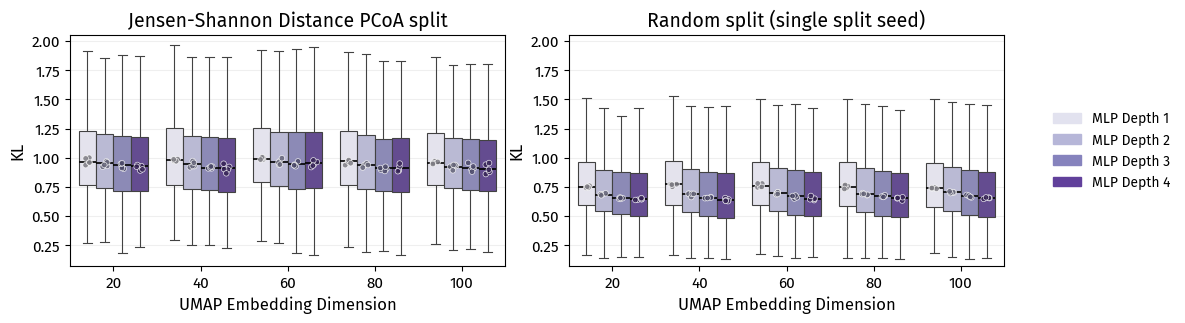

In [32]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sb
import pandas as pd
import numpy as np
from matplotlib.font_manager import FontProperties

# ==================== data
this_method_order = [
    'umap_d20_s1000__epc_pool_kl',  'umap_d20_s1000__epc_pool_1_kl', 'umap_d20_s1000__epc_pool_2_kl', 'umap_d20_s1000__epc_pool_3_kl',
    'umap_d40_s1000__epc_pool_kl',  'umap_d40_s1000__epc_pool_1_kl', 'umap_d40_s1000__epc_pool_2_kl', 'umap_d40_s1000__epc_pool_3_kl',
    'umap_d60_s1000__epc_pool_kl',  'umap_d60_s1000__epc_pool_1_kl', 'umap_d60_s1000__epc_pool_2_kl', 'umap_d60_s1000__epc_pool_3_kl',
    'umap_d80_s1000__epc_pool_kl',  'umap_d80_s1000__epc_pool_1_kl', 'umap_d80_s1000__epc_pool_2_kl', 'umap_d80_s1000__epc_pool_3_kl',
    'umap_d100_s1000__epc_pool_kl', 'umap_d100_s1000__epc_pool_1_kl', 'umap_d100_s1000__epc_pool_2_kl', 'umap_d100_s1000__epc_pool_3_kl',
]
pcoa_result_df = extract_concat_result(
    Path('results') / 'american_gut' / 'pcoa_split', this_method_order
)

# Load multiple data split seeds for the random split
rng_seeds_to_load = [100]  # extend this list once more splits are available
rng_result_dfs = {
    rng_seed: extract_concat_result(
        Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}',
        this_method_order,
    )
    for rng_seed in rng_seeds_to_load
}

# Construct a long-format dataframe with DataSplitSeed as a column
_sections = []
for rng_seed, df in rng_result_dfs.items():
    section = df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)


def darken_palette(palette, factor=0.55):
    """Return a darker version of a list of RGB tuples."""
    return [tuple(c * factor for c in color) for color in palette]


def plot_grouped_box_with_seed_dots(
    ax,
    data,
    x_col,
    hue_col,
    y_col,
    seed_cols,
    sample_col='SampleId',
    palette=None,
    showfliers=False,
    dot_size=4,
    dot_alpha=0.85,
    dot_edge='white',
    dot_edge_width=0.5,
    verbose=True,
):
    """
    Grouped boxplot with per-run median dots. See previous docstring.
    """
    active_seed_cols = [
        c for c in seed_cols
        if c in data.columns and not data[c].isna().all()
    ]

    # --- Print seed summary ---
    if verbose:
        print(f"  Active seed columns: {active_seed_cols}")
        for c in active_seed_cols:
            n_unique = data[c].nunique()
            unique_vals = sorted(data[c].dropna().unique().tolist())
            print(f"    {c}: {n_unique} unique values -> {unique_vals}")

        # Also report per-(x, hue) breakdown — useful for spotting missing seeds
        if active_seed_cols:
            per_group = (
                data.groupby([x_col, hue_col])[active_seed_cols]
                    .nunique()
                    .rename(columns={c: f'n_{c}' for c in active_seed_cols})
            )
            # Number of distinct runs per (x, hue) combination
            per_group['n_runs'] = (
                data.groupby([x_col, hue_col])
                    .apply(lambda g: g[active_seed_cols].drop_duplicates().shape[0])
            )
            print(f"  Per ({x_col}, {hue_col}) seed counts:")
            print(per_group.to_string())
        print()

    # --- (rest of the function unchanged) ---
    box_group_cols = [c for c in active_seed_cols if c != 'Seed']
    box_group_cols = box_group_cols + [x_col, hue_col, sample_col]
    box_data = (
        data.groupby(box_group_cols)[y_col]
            .mean()
            .reset_index()
    )

    sb.boxplot(
        box_data,
        x=x_col, y=y_col, hue=hue_col,
        palette=palette,
        ax=ax,
        legend=False,
        showfliers=showfliers,
        boxprops=dict(linewidth=0.8),
        whiskerprops=dict(linewidth=0.8),
        capprops=dict(linewidth=0.8),
        medianprops=dict(color='black', linewidth=1.2),
    )

    if active_seed_cols:
        dot_group_cols = active_seed_cols + [x_col, hue_col]
        per_run_median = (
            data.groupby(dot_group_cols)[y_col]
                .median()
                .reset_index()
        )

        if palette is not None:
            if isinstance(palette, dict):
                dot_palette = {k: darken_palette([v])[0] for k, v in palette.items()}
            else:
                dot_palette = darken_palette(palette)
        else:
            dot_palette = palette

        sb.stripplot(
            per_run_median,
            x=x_col, y=y_col, hue=hue_col,
            palette=dot_palette,
            ax=ax,
            legend=False,
            dodge=True,
            size=dot_size,
            alpha=dot_alpha,
            edgecolor=dot_edge,
            linewidth=dot_edge_width,
            jitter=0.15,
        )

    return ax


# ==================== plot
width = 14
height = 3
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10

fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(
    1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],
)




def parse_embed_dim(method_name: str) -> int:
    return int(method_name.split("_")[1][1:])

def parse_mlp_dim(method_name: str) -> int:
    pred_model = method_name.split("__")[1]
    return {'epc_pool_kl': 1, 'epc_pool_1_kl': 2,
            'epc_pool_2_kl': 3, 'epc_pool_3_kl': 4}[pred_model]


colors = sb.color_palette("Purples", 4)
mlp_colors = {1: colors[0], 2: colors[1], 3: colors[2], 4: colors[3]}

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# --- PCoA panel: only training seed varies ---
_pcoa = (
    pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
    .assign(
        EmbedDim=lambda d: d['Method'].map(parse_embed_dim),
        MLPDim=lambda d: d['Method'].map(parse_mlp_dim),
    )
)

print("=== PCoA panel ===")
plot_grouped_box_with_seed_dots(
    ax=ax1, data=_pcoa,
    x_col='EmbedDim', hue_col='MLPDim', y_col='KL_err',
    seed_cols=('Seed',), palette=mlp_colors,
)
ax1.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE,
               fontname="Fira Sans", fontweight='normal')
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans",
              fontweight='normal', fontsize=TITLE_FONT_SIZE)

# --- Random split panel: both data split seed AND training seed vary ---
_rng = (
    rng_full_df.loc[rng_full_df['Method'].isin(this_method_order)]
    .assign(
        EmbedDim=lambda d: d['Method'].map(parse_embed_dim),
        MLPDim=lambda d: d['Method'].map(parse_mlp_dim),
    )
)



print("=== Random panel ===")
plot_grouped_box_with_seed_dots(
    ax=ax2, data=_rng,
    x_col='EmbedDim', hue_col='MLPDim', y_col='KL_err',
    seed_cols=('DataSplitSeed', 'Seed'), palette=mlp_colors,
)
ax2.set_xlabel("UMAP Embedding Dimension", fontsize=FONT_SIZE,
               fontname="Fira Sans", fontweight='normal')
ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.sharey(ax1)
random_split_title = (
    f"Random split"
    if len(rng_seeds_to_load) > 1
    else "Random split (single split seed)"
)
ax2.set_title(random_split_title, fontname="Fira Sans",
              fontweight='normal', fontsize=TITLE_FONT_SIZE)

# --- Legend panel ---
legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [
    mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}')
    for mlp_dim in [1, 2, 3, 4]
]
legend_ax.legend(handles=handles, loc="center", frameon=False,
                 title="Methods", ncols=1)

custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_metrics_umap_range.pdf",
            bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_metrics_umap_range.png",
            dpi=800, bbox_inches='tight', transparent=True)
print("done")

In [27]:
# import matplotlib.pyplot as plt


# # ==================== data
# torch_models_to_plot = [
#     'dnabert-s__epc_pool_kl',
#     'dnabert-s__epc_pool_1_kl',
#     'dnabert-s__epc_pool_2_kl',
#     'dnabert-s__epc_pool_3_kl',
    
#     'evo-1-8k-base_hyena5__epc_pool_kl',
#     'evo-1-8k-base_hyena5__epc_pool_1_kl',
#     'evo-1-8k-base_hyena5__epc_pool_2_kl',
#     'evo-1-8k-base_hyena5__epc_pool_3_kl',
    
#     'evo2_7b_hyena10__epc_pool_kl',
#     'evo2_7b_hyena10__epc_pool_1_kl',
#     'evo2_7b_hyena10__epc_pool_2_kl',
#     'evo2_7b_hyena10__epc_pool_3_kl',
# ]
# pcoa_result_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)
# rng_result_dfs = {
#     rng_seed: extract_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', torch_models_to_plot)
#     for rng_seed in [100]
# }


# # ==================== plot
# width = 14
# height = 3
# FONT_SIZE = 12
# TITLE_FONT_SIZE = 14
# LEGEND_FONT_SIZE = 10
# xtick_angle = 50

# EMBED_DISPLAY_NAMES = {
#     'dnabert-s': "DNABERT-S",
#     'evo-1-8k-base_hyena5': "Evo",
#     'evo2_7b_hyena10': "Evo 2",
# }

# fig = plt.figure(figsize=(width, height))
# gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],)

# this_method_order = torch_models_to_plot

# _result = pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])


# def parse_embed_type(method_name: str) -> str:
#     tokens = method_name.split("__")
#     return EMBED_DISPLAY_NAMES[tokens[0]]

# def parse_mlp_dim(method_name: str) -> int:
#     tokens = method_name.split("__")
#     pred_model = tokens[1]
#     if pred_model == "epc_pool_kl":
#         return 1
#     elif pred_model == "epc_pool_1_kl":
#         return 2
#     elif pred_model == "epc_pool_2_kl":
#         return 3
#     elif pred_model == "epc_pool_3_kl":
#         return 4
        
# colors = sb.color_palette("Blues", 4)
# mlp_colors = {
#     1: colors[0],
#     2: colors[1],
#     3: colors[2],
#     4: colors[3],
# }

# _result = _result.assign(EmbedType=_result['Method'].map(parse_embed_type), MLPDim=_result['Method'].map(parse_mlp_dim))
# sb.boxplot(
#     _result,
#     x='EmbedType', y='KL_err', hue='MLPDim', palette=mlp_colors,
#     ax=ax1,
#     legend=False,
#     showfliers=False,
# )
# ax1.set_xlabel(None, fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)


# rng_seed_to_show = 100
# _result = rng_result_dfs[rng_seed_to_show]
# _result = _result.loc[_result['Method'].isin(this_method_order)]
# _result = _result.assign(EmbedType=_result['Method'].map(parse_embed_type), MLPDim=_result['Method'].map(parse_mlp_dim))
# sb.boxplot(
#     _result,
#     x='EmbedType', y='KL_err', hue='MLPDim', palette=mlp_colors,
#     ax=ax2,
#     legend=False,
#     showfliers=False,
# )
# ax2.set_xlabel(None, fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
# ax2.sharey(ax1)
# ax2.set_title("Random split (single seed)", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)

# legend_ax = fig.add_subplot(gs[0, -1])
# legend_ax.axis("off")
# handles = [mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}') for mlp_dim in [1, 2, 3, 4]]
# legend_ax.legend(
#     handles=handles, loc="center", 
#     frameon=False, title="Methods", ncols=1,
# )

# from matplotlib.font_manager import FontProperties
# custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
# for ax in [ax1, ax2]:
#     ax.grid(axis="y", linestyle="-", alpha=0.2)
#     for label in ax.get_xticklabels():
#         label.set_fontproperties(custom_font)
#     for label in ax.get_yticklabels():
#         label.set_fontproperties(custom_font)


# legend_ax.get_legend().set_title("", prop=custom_font)
# for text in legend_ax.get_legend().get_texts():
#     text.set_fontsize(LEGEND_FONT_SIZE)
#     text.set_fontfamily("Fira Sans")
#     text.set_fontweight("normal")

# plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.pdf", bbox_inches='tight', transparent=True)
# plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.png", dpi=800, bbox_inches='tight', transparent=True)
# print("done")

=== PCoA panel ===
  Active seed columns: ['Seed']
    Seed: 5 unique values -> [12345, 12346, 12347, 12348, 12349]
  Per (EmbedType, MLPDim) seed counts:
                  n_Seed  n_runs
EmbedType MLPDim                
DNABERT-S 1            5       5
          2            5       5
          3            5       5
          4            5       5
Evo       1            5       5
          2            5       5
          3            5       5
          4            5       5
Evo 2     1            5       5
          2            5       5
          3            5       5
          4            5       5

=== Random panel ===
  Active seed columns: ['DataSplitSeed', 'Seed']
    DataSplitSeed: 1 unique values -> [100]
    Seed: 5 unique values -> [12345, 12346, 12347, 12348, 12349]
  Per (EmbedType, MLPDim) seed counts:
                  n_DataSplitSeed  n_Seed  n_runs
EmbedType MLPDim                                 
DNABERT-S 1                     1       5       5
          2   

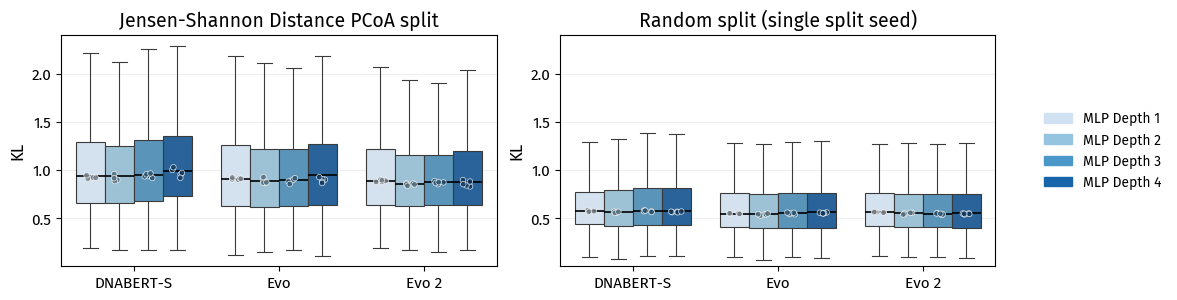

In [33]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sb
import pandas as pd
from matplotlib.font_manager import FontProperties

# ==================== data
torch_models_to_plot = [
    'dnabert-s__epc_pool_kl',
    'dnabert-s__epc_pool_1_kl',
    'dnabert-s__epc_pool_2_kl',
    'dnabert-s__epc_pool_3_kl',

    'evo-1-8k-base_hyena5__epc_pool_kl',
    'evo-1-8k-base_hyena5__epc_pool_1_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_3_kl',

    'evo2_7b_hyena10__epc_pool_kl',
    'evo2_7b_hyena10__epc_pool_1_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_3_kl',
]
pcoa_result_df = extract_concat_result(
    Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot
)

# Load multiple data split seeds for the random split (extend list as more become available)
rng_seeds_to_load = [100]
rng_result_dfs = {
    rng_seed: extract_concat_result(
        Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}',
        torch_models_to_plot,
    )
    for rng_seed in rng_seeds_to_load
}

# Construct long-format dataframe with DataSplitSeed as a column
_sections = []
for rng_seed, df in rng_result_dfs.items():
    section = df.copy()
    section['DataSplitSeed'] = rng_seed
    _sections.append(section)
rng_full_df = pd.concat(_sections, ignore_index=True)


# ==================== plot
width = 14
height = 3
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10

EMBED_DISPLAY_NAMES = {
    'dnabert-s': "DNABERT-S",
    'evo-1-8k-base_hyena5': "Evo",
    'evo2_7b_hyena10': "Evo 2",
}

fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(
    1, 3, figure=fig, hspace=0.1, wspace=0.2, width_ratios=[1, 1, 0.2],
)

this_method_order = torch_models_to_plot


def parse_embed_type(method_name: str) -> str:
    return EMBED_DISPLAY_NAMES[method_name.split("__")[0]]

def parse_mlp_dim(method_name: str) -> int:
    pred_model = method_name.split("__")[1]
    return {'epc_pool_kl': 1, 'epc_pool_1_kl': 2,
            'epc_pool_2_kl': 3, 'epc_pool_3_kl': 4}[pred_model]


colors = sb.color_palette("Blues", 4)
mlp_colors = {1: colors[0], 2: colors[1], 3: colors[2], 4: colors[3]}

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# --- PCoA panel: only training seed varies ---
_pcoa = (
    pcoa_result_df.loc[pcoa_result_df['Method'].isin(this_method_order)]
    .assign(
        EmbedType=lambda d: d['Method'].map(parse_embed_type),
        MLPDim=lambda d: d['Method'].map(parse_mlp_dim),
    )
)

print("=== PCoA panel ===")
plot_grouped_box_with_seed_dots(
    ax=ax1,
    data=_pcoa,
    x_col='EmbedType',
    hue_col='MLPDim',
    y_col='KL_err',
    seed_cols=('Seed',),
    palette=mlp_colors,
)
ax1.set_xlabel(None)
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_title("Jensen-Shannon Distance PCoA split", fontname="Fira Sans",
              fontweight='normal', fontsize=TITLE_FONT_SIZE)

# --- Random split panel: both data split seed AND training seed vary ---
_rng = (
    rng_full_df.loc[rng_full_df['Method'].isin(this_method_order)]
    .assign(
        EmbedType=lambda d: d['Method'].map(parse_embed_type),
        MLPDim=lambda d: d['Method'].map(parse_mlp_dim),
    )
)

print("=== Random panel ===")
plot_grouped_box_with_seed_dots(
    ax=ax2,
    data=_rng,
    x_col='EmbedType',
    hue_col='MLPDim',
    y_col='KL_err',
    seed_cols=('DataSplitSeed', 'Seed'),
    palette=mlp_colors,
)
ax2.set_xlabel(None)
ax2.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax2.sharey(ax1)
random_split_title = (
    "Random split"
    if len(rng_seeds_to_load) > 1
    else "Random split (single split seed)"
)
ax2.set_title(random_split_title, fontname="Fira Sans",
              fontweight='normal', fontsize=TITLE_FONT_SIZE)

# --- Legend panel ---
legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [
    mpatches.Patch(color=mlp_colors[mlp_dim], label=f'MLP Depth {mlp_dim}')
    for mlp_dim in [1, 2, 3, 4]
]
legend_ax.legend(handles=handles, loc="center", frameon=False,
                 title="Methods", ncols=1)

custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)
for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")

plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.pdf",
            bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_metrics_mlp_layer_comparison.png",
            dpi=800, bbox_inches='tight', transparent=True)
print("done")

## Ablation results

In [34]:
# ==================== dataframes
def extract_ablation_concat_result(results_dir: Path, method_names: List):
    eval_result_dfs = []
    
    # torch models
    for method_name in method_names:
        for tsv_path in results_dir.glob(f"{method_name}__*.tsv"):
            seed_value = int(tsv_path.stem.split("__")[-1])
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name, Ablated=False, Seed=seed_value
                )
            )
        for tsv_path in results_dir.glob(f"ABLATED__{method_name}__*.tsv"):
            seed_value = int(tsv_path.stem.split("__")[-1])
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name, Ablated=True, Seed=seed_value
                )
            )
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [35]:
# # embed_models_to_plot = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
# # embed_models_to_plot += ['umap_d20_s1000', 'umap_d40_s1000', 'umap_d60_s1000', 'umap_d80_s1000', 'umap_d100_s1000']
# # pred_models_to_plot = ['epc_pool_kl', 'epc_pool_1_kl', 'epc_pool_2_kl', 'epc_pool_3_kl']
# # baseline_methods = ['uniform', 'asv_nearest_neighbor', 'asv_nearest_neighbor_withinproj']
# # baseline_methods += [f'asv_nearest_neighbor_KNN_{i}' for i in (10, 20, 30, 40)]

# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'DNABERT-S', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'Evo 1', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'Evo 2', 'Evo 2'),
#     TorchInferenceCategory('umap_d100_s1000', 'UMAP (d=100)', 'UMAP ($d=100$)'),
# ]
# pred_models_to_plot = [
#     PredCategory('epc_pool_3_kl','MLP Depth 4', 'MLP Depth 4'),
#     # PredCategory('set_transformer_kl', 'Set-Transformer', 'Set-Transformer'),
# ]
# pcoa_ablation_result_df = extract_ablation_concat_result(Path('results') / 'american_gut' / 'pcoa_split', embed_models_to_plot, pred_models_to_plot)


# embed_models_to_plot = [
#     TorchInferenceCategory('dnabert-s', 'DNABERT-S', 'DNABERT-S'), 
#     TorchInferenceCategory('evo-1-8k-base_hyena5', 'Evo 1', 'Evo 1'), 
#     TorchInferenceCategory('evo2_7b_hyena10', 'Evo 2', 'Evo 2'),
#     TorchInferenceCategory('umap_d100_s1000', 'UMAP (d=100)', 'UMAP ($d=100$)'),
# ]
# pred_models_to_plot = [
#     PredCategory('epc_pool_3_kl','MLP Depth 4', 'MLP Depth 4'),
#     PredCategory('epc_nopool_3_kl','MLP Depth 4', 'MLP Depth 4'),
# ]
# pool_vs_nopool_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', [], embed_models_to_plot, pred_models_to_plot)
# # rng_ablation_result_dfs = {
# #     rng_seed: extract_ablation_concat_result(Path('results') / 'american_gut' / f'random_split_seed_{rng_seed}', embed_models_to_plot, pred_models_to_plot)
# #     for rng_seed in [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
# # }

In [36]:
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd


def pool_vs_nopool_boxplot(
    df,
    ax,
    font_size,
    embed_palette,
    seed_cols=('Seed',),
    sample_col='SampleId',
    y_col='KL_err',
    dot_size=20,
    dot_alpha=0.9,
    dot_edge='white',
    dot_edge_width=0.5,
    rng_seed=0,
    verbose=True,
):
    """
    Grouped pool-vs-nopool boxplot with per-seed median dots overlaid.
    
    Boxes show distribution of per-sample losses (training seeds averaged per
    sample, within each data split if present). Dots show per-run (per
    seed_cols combination) median across the test set.
    """
    # --- Build the pooled/not-pooled tagged frame ---
    ablation_df = pd.concat([
        df.loc[df['Method'].str.contains("_pool_")].assign(Pooled=True),
        df.loc[df['Method'].str.contains("_nopool_")].assign(Pooled=False),
    ], ignore_index=True)
    ablation_df['Embedding'] = ablation_df['Method'].str.split("__").str[0]

    EMBEDDING_NAMES = [
        'dnabert-s', 'evo-1-8k-base_hyena5',
        'evo2_7b_hyena10', 'umap_d100_s1000',
    ]
    HATCH_PATTERNS = {True: "", False: "///"}

    group_width = 0.8
    box_width = group_width / 2
    offsets = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
        len([True, False]),
    )

    # --- Active seed columns ---
    active_seed_cols = [
        c for c in seed_cols
        if c in ablation_df.columns and not ablation_df[c].isna().all()
    ]

    if verbose:
        print(f"  Active seed columns: {active_seed_cols}")
        for c in active_seed_cols:
            n_unique = ablation_df[c].nunique()
            unique_vals = sorted(ablation_df[c].dropna().unique().tolist())
            print(f"    {c}: {n_unique} unique values -> {unique_vals}")

    # --- Boxplot data: average training seeds within each (split, sample, embedding, pooled) ---
    box_group_cols = [c for c in active_seed_cols if c != 'Seed']
    box_group_cols = box_group_cols + ['Embedding', 'Pooled', sample_col]
    box_data = (
        ablation_df.groupby(box_group_cols)[y_col]
                   .mean()
                   .reset_index()
    )

    # --- Dot data: per-run median across samples ---
    per_run_median = None
    if active_seed_cols:
        dot_group_cols = active_seed_cols + ['Embedding', 'Pooled']
        per_run_median = (
            ablation_df.groupby(dot_group_cols)[y_col]
                       .median()
                       .reset_index()
        )

    rng = np.random.default_rng(rng_seed)

    for i, embed_name in enumerate(EMBEDDING_NAMES):
        color = embed_palette[embed_name]
        dot_color = tuple(float(c) * 0.55 for c in color[:3])

        for j, is_pooled in enumerate([True, False]):
            # --- Boxplot ---
            box_subset = box_data[
                (box_data["Pooled"] == is_pooled)
                & (box_data["Embedding"] == embed_name)
            ][y_col]

            if box_subset.empty:
                continue

            pos = i + offsets[j]
            hatch = HATCH_PATTERNS[is_pooled]

            bp = ax.boxplot(
                box_subset,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
                medianprops=dict(color="black", linewidth=1),
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.85)
                patch.set_hatch(hatch)

            # --- Per-seed dots ---
            if per_run_median is not None:
                dot_vals = per_run_median[
                    (per_run_median["Pooled"] == is_pooled)
                    & (per_run_median["Embedding"] == embed_name)
                ][y_col].values

                if len(dot_vals) > 0:
                    jitter = rng.uniform(
                        -box_width * 0.25,
                        box_width * 0.25,
                        size=len(dot_vals),
                    )
                    x_pos = np.full(len(dot_vals), pos) + jitter

                    ax.scatter(
                        x_pos, dot_vals,
                        s=dot_size,
                        color=dot_color,
                        edgecolor=dot_edge,
                        linewidth=dot_edge_width,
                        alpha=dot_alpha,
                        zorder=10,
                    )

    # --- Legend (unchanged) ---
    ablation_handles = [
        mpatches.Patch(facecolor="white", edgecolor="black",
                       hatch=HATCH_PATTERNS[True], label="Pooling"),
        mpatches.Patch(facecolor="white", edgecolor="black",
                       hatch=HATCH_PATTERNS[False], label="No Pooling"),
    ]
    leg2 = ax.legend(
        handles=ablation_handles, title=None,
        loc="upper left", bbox_to_anchor=(0, 1),
        prop={'family': 'Fira Sans', 'weight': 'normal'},
        fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE + 1,
        frameon=True,
    )
    ax.add_artist(leg2)

In [37]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from typing import List, Dict


def ablation_boxplot(
    df,
    ax,
    method_order: List[str],
    method_names: Dict[str, str],
    method_palette: Dict[str, np.ndarray],
    y_col: str,
    seed_cols=('Seed',),
    sample_col='SampleId',
    dot_size=20,
    dot_alpha=0.9,
    dot_edge='white',
    dot_edge_width=0.5,
    rng_seed=0,
    verbose=True,
):
    """
    Grouped ablation boxplot with per-seed median dots overlaid.
    
    Boxes show distribution of per-sample losses (training seeds averaged per
    sample, within each data split if present). Dots show per-run (per
    seed_cols combination) median across the test set.
    """
    HATCH_PATTERNS = {False: "", True: "///"}
    group_width = 0.8
    box_width = group_width / 2
    offsets = np.linspace(
        -group_width / 2 + box_width / 2,
         group_width / 2 - box_width / 2,
        len([True, False]),
    )

    # --- Determine active seed columns ---
    active_seed_cols = [
        c for c in seed_cols
        if c in df.columns and not df[c].isna().all()
    ]

    if verbose:
        print(f"  Active seed columns: {active_seed_cols}")
        for c in active_seed_cols:
            n_unique = df[c].nunique()
            unique_vals = sorted(df[c].dropna().unique().tolist())
            print(f"    {c}: {n_unique} unique values -> {unique_vals}")

    # --- Boxplot data: average training seeds within each (split, sample, method, ablated) ---
    box_group_cols = [c for c in active_seed_cols if c != 'Seed']
    box_group_cols = box_group_cols + ['Method', 'Ablated', sample_col]
    box_data = (
        df.groupby(box_group_cols)[y_col]
          .mean()
          .reset_index()
    )

    # --- Dot data: per-run median across samples ---
    per_run_median = None
    if active_seed_cols:
        dot_group_cols = active_seed_cols + ['Method', 'Ablated']
        per_run_median = (
            df.groupby(dot_group_cols)[y_col]
              .median()
              .reset_index()
        )

    rng = np.random.default_rng(rng_seed)

    for i, method in enumerate(method_order):
        color = method_palette[method]
        # Darker dot color (handle both RGB tuple and array forms)
        dot_color = tuple(float(c) * 0.55 for c in color[:3])

        for j, is_ablated in enumerate([False, True]):
            # --- Boxplot ---
            box_subset = box_data[
                (box_data["Ablated"] == is_ablated)
                & (box_data["Method"] == method)
            ][y_col]

            if box_subset.empty:
                continue

            pos = i + offsets[j]
            hatch = HATCH_PATTERNS[is_ablated]

            bp = ax.boxplot(
                box_subset,
                positions=[pos],
                widths=box_width,
                patch_artist=True,
                manage_ticks=False,
                showfliers=False,
                medianprops=dict(color="black", linewidth=1),
            )

            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.85)
                patch.set_hatch(hatch)

            # --- Per-seed dots ---
            if per_run_median is not None:
                dot_vals = per_run_median[
                    (per_run_median["Ablated"] == is_ablated)
                    & (per_run_median["Method"] == method)
                ][y_col].values

                if len(dot_vals) > 0:
                    jitter = rng.uniform(
                        -box_width * 0.25,
                        box_width * 0.25,
                        size=len(dot_vals),
                    )
                    x_pos = np.full(len(dot_vals), pos) + jitter

                    ax.scatter(
                        x_pos, dot_vals,
                        s=dot_size,
                        color=dot_color,
                        edgecolor=dot_edge,
                        linewidth=dot_edge_width,
                        alpha=dot_alpha,
                        zorder=10,
                    )

    # --- Legend (unchanged) ---
    ablation_handles = [
        mpatches.Patch(facecolor="white", edgecolor="black",
                       hatch=HATCH_PATTERNS[False], label="Full Model"),
        mpatches.Patch(facecolor="white", edgecolor="black",
                       hatch=HATCH_PATTERNS[True], label="Ablated Model"),
    ]
    leg2 = ax.legend(
        handles=ablation_handles, title=None,
        loc="upper left", bbox_to_anchor=(0, 1),
        prop={'family': 'Fira Sans', 'weight': 'normal'},
        fontsize=LEGEND_FONT_SIZE, title_fontsize=LEGEND_FONT_SIZE + 1,
        frameon=True,
    )
    ax.add_artist(leg2)

,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumASV,NumParameters,Method,Ablated,Seed
0,ERS6283731,2.160289,0.723104,0.695971,0.740097,0.638623,98,90145,dnabert-s__epc_pool_2_kl,False,12348
1,ERS6283728,0.920030,0.797086,0.666157,0.577261,0.458740,99,90145,dnabert-s__epc_pool_2_kl,False,12348
2,ERS6283726,0.422800,0.656748,0.686516,0.324907,0.336841,109,90145,dnabert-s__epc_pool_2_kl,False,12348
3,ERS6283724,1.445143,0.796346,0.637359,0.656688,0.550421,121,90145,dnabert-s__epc_pool_2_kl,False,12348
4,ERS6283723,0.897096,0.846626,0.595866,0.591231,0.487962,107,90145,dnabert-s__epc_pool_2_kl,False,12348
...,...,...,...,...,...,...,...,...,...,...,...
30835,ERS4851158,1.558184,0.802482,0.145906,0.684455,0.558038,142,47393,umap_d100_s1000__epc_pool_2_kl,True,12347
30836,ERS7061585,2.132425,0.984489,0.375272,0.713641,0.600875,126,47393,umap_d100_s1000__epc_pool_2_kl,True,12347
30837,ERS7061584,1.988566,0.902761,0.426933,0.703417,0.584217,136,47393,umap_d100_s1000__epc_pool_2_kl,True,12347
30838,ERS7061496,2.127417,1.208964,0.116047,0.787106,0.639874,95,47393,umap_d100_s1000__epc_pool_2_kl,True,12347


  Active seed columns: ['Seed']
    Seed: 5 unique values -> [12345, 12346, 12347, 12348, 12349]
  Active seed columns: ['Seed']
    Seed: 5 unique values -> [12345, 12346, 12347, 12348, 12349]
done


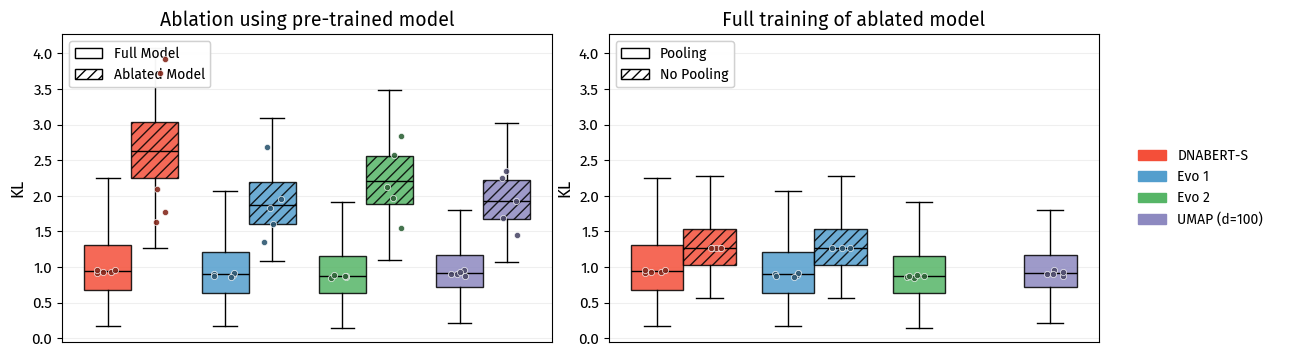

In [38]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ==================== data
torch_models_to_plot = [
    'dnabert-s__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
]
pcoa_ablation_result_df = extract_ablation_concat_result(Path('results') / 'american_gut' / 'pcoa_split', torch_models_to_plot)


# ==================== plot
width = 16
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 30


fig = plt.figure(figsize=(width, height))
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.05, wspace=0.15, width_ratios=[1, 1, 0.3], height_ratios=[1])

name_mapping = defaultdict(lambda: "asdf")


ax1 = fig.add_subplot(gs[0, 0])  # Spans rows 0-1, column 0
ax2 = fig.add_subplot(gs[0, 1])  # Spans rows 0-1, column 1

# display(pd.unique(_result['Method']))
this_method_order = torch_models_to_plot
plot_palette = {
    'dnabert-s__epc_pool_2_kl': sb.color_palette('Reds', n_colors=6)[3],
    'evo-1-8k-base_hyena5__epc_pool_2_kl': sb.color_palette('Blues', n_colors=6)[3],
    'evo2_7b_hyena10__epc_pool_2_kl': sb.color_palette('Greens', n_colors=6)[3],
    'umap_d100_s1000__epc_pool_2_kl': sb.color_palette('Purples', n_colors=6)[3],
}

_result = pcoa_ablation_result_df.loc[pcoa_ablation_result_df['Method'].isin(this_method_order)]
display(_result)
# boxplot_with_paired_significance(_result, hue='Method', y='KL_err', sample_col='Sample', ax=ax1, palette=plot_palette, hue_order=this_method_order, annot_pvals=False, fontsize=FONT_SIZE)
ablation_boxplot(_result, ax1, this_method_order, name_mapping, plot_palette, 'KL_err')
ax1.set_ylabel("KL", fontsize=FONT_SIZE, fontname="Fira Sans", fontweight='normal')
ax1.set_xlabel(None)
# ax1.set_xticks(range(len(this_method_order)), [name_mapping[_m] for _m in this_method_order], rotation=xtick_angle, ha='right', rotation_mode='anchor', fontname="Fira Sans", fontweight='normal')
ax1.set_xticks([])
ax1.set_title("Ablation using pre-trained model", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
# ax1.get_legend().set_loc("upper right")


embed_palette = {
    'dnabert-s': plot_palette['dnabert-s__epc_pool_2_kl'],
    'evo-1-8k-base_hyena5': plot_palette['evo-1-8k-base_hyena5__epc_pool_2_kl'],
    'evo2_7b_hyena10': plot_palette['evo2_7b_hyena10__epc_pool_2_kl'],
    'umap_d100_s1000': plot_palette['umap_d100_s1000__epc_pool_2_kl'],
}
method_names = {
    'dnabert-s': 'DNABERT-S',
    'evo-1-8k-base_hyena5': 'Evo 1',
    'evo2_7b_hyena10': 'Evo 2',
    'umap_d100_s1000': 'UMAP (d=100)',
}


pool_vs_nopool_df = extract_concat_result(Path('results') / 'american_gut' / 'pcoa_split', [
    'dnabert-s__epc_pool_2_kl',
    'dnabert-s__epc_nopool_2_kl',
    'evo-1-8k-base_hyena5__epc_pool_2_kl',
    'evo-1-8k-base_hyena5__epc_nopool_2_kl',
    'evo2_7b_hyena10__epc_pool_2_kl',
    'evo2_7b_hyena10__epc_nopool_2_kl',
    'umap_d100_s1000__epc_pool_2_kl',
    'umap_d100_s1000__epc_nopool_2_kl',
])
pool_vs_nopool_boxplot(pool_vs_nopool_df, ax2, font_size=FONT_SIZE, embed_palette=embed_palette)
ax2.set_ylabel("KL", fontname="Fira Sans", fontweight='normal', fontsize=FONT_SIZE)
ax2.set_title("Full training of ablated model", fontname="Fira Sans", fontweight='normal', fontsize=TITLE_FONT_SIZE)
ax2.set_xticks([])
ax2.sharey(ax1)


from matplotlib.font_manager import FontProperties
custom_font = FontProperties(family='Fira Sans', weight='normal', size=11)

# draw legend for methods
legend_ax = fig.add_subplot(gs[0, -1])
legend_ax.axis("off")
handles = [mpatches.Patch(color=embed_palette[_method], label=method_names[_method]) for _method in method_names.keys()]
legend_ax.legend(
    handles=handles, loc="center left", bbox_to_anchor=(-0.2, 0.5, 0.0, 0.0),
    frameon=False, title="Embeddings", ncols=1,
)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")



for ax in [ax1, ax2]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)

plt.savefig("results/american_gut/asv_ablation.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/asv_ablation.png", dpi=800, bbox_inches='tight', transparent=True)
print("done")

# Parameter count ablation

In [39]:
embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
pred_models = []
pred_models += [f'epc_pool_scaling{sz}_kl' for sz in [4, 5, 7, 9, 12, 15, 20, 26, 34, 44, 57, 64, 74, 97, 126, 163, 211, 274, 356, 462, 512]]
pred_models += [f'epc_pool_scaling{sz}_NO_MLP_kl' for sz in [4, 5, 6, 8, 10, 13, 16, 20, 26, 32, 33, 42, 53, 68, 86, 109, 138, 175, 221, 279, 256]]
pred_models += [f'set_transformer_d{sz}_kl' for sz in [8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 64]]

dset_name = "american_gut"
analysis_name = "pcoa_split"
evaluate_all(dset_name, analysis_name, results_dir=Path("results") / dset_name / analysis_name, overwrite=False, exclude_baseline=True)
# /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/evo-1-8k-base_hyena5/set_transformer_d16_kl/model_config.json

Embed model = dnabert-s
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 12765 embeddings in memory.
	Pred model = epc_pool_scaling4_kl
	Seed value = 12345
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12345
Output for dnabert-s: epc_pool_scaling4_kl [seed=12345] already exists!
	Seed value = 12346
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12346
Output for dnabert-s: epc_pool_scaling4_kl [seed=12346] already exists!
	Seed value = 12347
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut/analyses/pcoa_split/trained_models/dnabert-s/epc_pool_scaling4_kl/seed_12347
Output for dnabert-s: epc_pool_scali

In [40]:
def extract_concat_result_scaling(results_dir: Path, method_names: List):
    eval_result_dfs = []
    
    # torch models
    for method_name in method_names:
        for tsv_path in results_dir.glob(f"{method_name}_kl__*.tsv"):
            seed_value = int(tsv_path.stem.split("__")[-1])
            embed_name = method_name.split("__")[0]
            eval_result_dfs.append(
                pd.read_csv(tsv_path, sep='\t').assign(
                    Method=method_name,
                    Embedding=embed_name,
                    Seed=seed_value,
                )
            )
    
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    return eval_result_df

In [41]:
epc_pool_sizes = [4, 5, 7, 9, 12, 15, 20, 26, 34, 44, 57, 64, 74, 97, 126, 163, 211, 274, 356, 462, 512]
epc_pool_no_mlp_sizes = [4, 5, 6, 8, 10, 13, 16, 20, 26, 32, 33, 42, 53, 68, 86, 109, 138, 175, 221, 279, 256]
set_transformer_sizes = [8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64]

scaling_est_df = extract_concat_result_scaling(
    Path("results") / "american_gut" / "pcoa_split",
    [f'dnabert-s__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'evo-1-8k-base_hyena5__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'evo2_7b_hyena10__epc_pool_scaling{sz}' for sz in epc_pool_sizes] 
    + [f'dnabert-s__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'evo-1-8k-base_hyena5__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'evo2_7b_hyena10__epc_pool_scaling{sz}_NO_MLP' for sz in epc_pool_no_mlp_sizes] 
    + [f'dnabert-s__set_transformer_d{sz}' for sz in set_transformer_sizes] 
    + [f'evo-1-8k-base_hyena5__set_transformer_d{sz}' for sz in set_transformer_sizes] 
    + [f'evo2_7b_hyena10__set_transformer_d{sz}' for sz in set_transformer_sizes] 
)

In [45]:
print_missing_seeds(scaling_est_df)

Expected seeds: [np.int64(12345), np.int64(12346), np.int64(12347)]
Problematic method evals:


In [46]:
""" Parse method names """
def parse_method_names(df: pd.DataFrame):
    def __model_type(x: str) -> str:
        tokens = x.split("__")
        assert len(tokens) == 2
        pred_name = tokens[1]
        if "epc" in pred_name:
            if "_NO_MLP" in pred_name:
                return "SAGE-MP (No MLP)"
            else:
                return "SAGE-MP (With MLP)"
        elif "set_transformer" in pred_name:
            return "SAGE-ST"
            
    return df.assign(ModelType=df['Method'].map(__model_type))


scaling_est_df = parse_method_names(scaling_est_df)
display(scaling_est_df)

,SampleId,KL_err,RMSL_err,SpearmanCorr,BrayCurtis,RootJensenShannon,NumASV,NumParameters,Method,Embedding,Seed,ModelType
0,ERS6283731,1.666677,1.175239,0.535502,0.737639,0.594604,98,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
1,ERS6283728,1.135523,0.971896,0.450487,0.618591,0.503587,99,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
2,ERS6283726,1.016253,1.038071,0.451337,0.589486,0.493145,109,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
3,ERS6283724,2.117092,1.058192,0.517685,0.730965,0.606975,121,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
4,ERS6283723,1.556055,1.055194,0.518531,0.731648,0.583423,107,4465,dnabert-s__epc_pool_scaling4,dnabert-s,12345,SAGE-MP (With MLP)
...,...,...,...,...,...,...,...,...,...,...,...,...
388579,ERS4851158,0.986244,0.630334,0.463811,0.598725,0.485848,142,1116545,evo2_7b_hyena10__set_transformer_d64,evo2_7b_hyena10,12345,SAGE-ST
388580,ERS7061585,0.575644,0.680515,0.678024,0.477938,0.387519,126,1116545,evo2_7b_hyena10__set_transformer_d64,evo2_7b_hyena10,12345,SAGE-ST
388581,ERS7061584,0.736922,0.532707,0.729408,0.531215,0.436306,136,1116545,evo2_7b_hyena10__set_transformer_d64,evo2_7b_hyena10,12345,SAGE-ST
388582,ERS7061496,1.518352,1.026269,0.348463,0.725884,0.584247,95,1116545,evo2_7b_hyena10__set_transformer_d64,evo2_7b_hyena10,12345,SAGE-ST


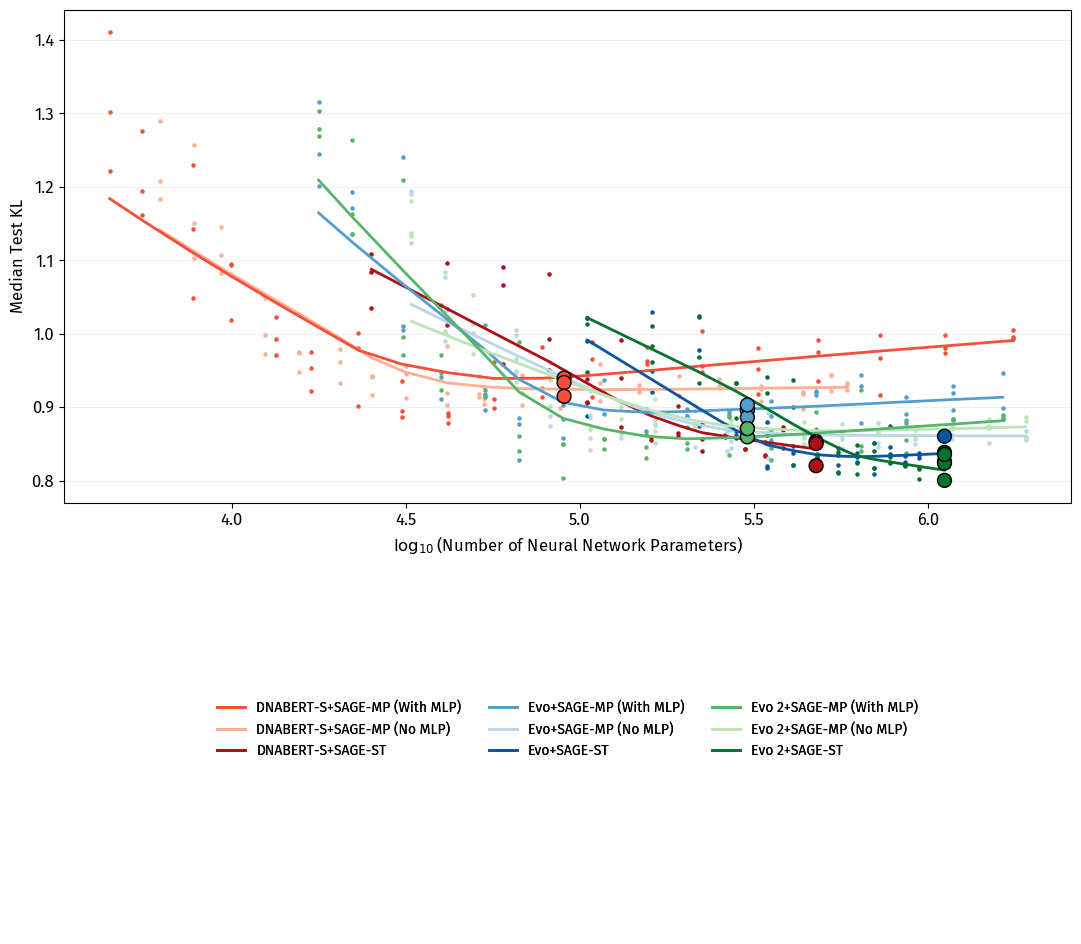

In [47]:
import matplotlib
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

custom_font = FontProperties(family='Fira Sans', weight='normal', size=12)
width = 16
height = 4
FONT_SIZE = 12
TITLE_FONT_SIZE = 14
LEGEND_FONT_SIZE = 10
xtick_angle = 30


def render_empirical_scaling(full_df, ax, colors, linestyles, embedding_names, agg_type = 'mean'):
    if agg_type == 'mean':
        df = full_df.groupby(["Method", "Embedding", 'ModelType', 'Seed'])[['NumParameters', 'KL_err']].mean().reset_index()
    elif agg_type == 'median':
        df = full_df.groupby(["Method", "Embedding", 'ModelType', 'Seed'])[['NumParameters', 'KL_err']].median().reset_index()
    else:
        raise ValueError(f"Unrecognized aggregation type: {agg_type}")
    for (embedding_model, model_type), embedding_section in df.groupby(["Embedding", "ModelType"]):
        # if embedding_model != 'evo-1-8k-base_hyena5':
        #     continue
        # display(embedding_section)
        embedding_name = embedding_names[embedding_model]
        embedding_section = embedding_section.assign(
            KL_err_log=np.log10(embedding_section['KL_err']),
            NumParameters_log=np.log10(embedding_section['NumParameters'])
        )
        color = colors[embedding_model][model_type]
        
        sb.regplot(
            embedding_section,
            scatter=True,
            x='NumParameters_log',
            y='KL_err',
            color=color,
            ax=ax,
            ci=95,
            label=f'{embedding_name}: {model_type}',
            # logx=True,
            lowess=True,
            marker='.',
            scatter_kws={'s': 20, 'alpha': 1.0},
            line_kws={'lw': 2, 'linestyle': linestyles[model_type]},
        )

    for plotted_element in ax.collections:
        if isinstance(plotted_element, matplotlib.collections.FillBetweenPolyCollection):
            plt.setp(plotted_element, alpha=0.2)  # change transparency of CI bands


width = 13
height = 12

fig = plt.figure(figsize=(width, height))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], wspace=0.2, hspace=0.5)

ax1 = fig.add_subplot(gs[0, :])
# ax2 = fig.add_subplot(gs[0, 1])
# ax2.sharey(ax1)

embedding_names = {'dnabert-s': 'DNABERT-S', 'evo-1-8k-base_hyena5': 'Evo', 'evo2_7b_hyena10': 'Evo 2'}
regplot_colors = {
    'dnabert-s': { 'SAGE-MP (No MLP)': sb.color_palette('Reds', n_colors=6)[1], 'SAGE-MP (With MLP)': sb.color_palette('Reds', n_colors=6)[3], 'SAGE-ST': sb.color_palette('Reds', n_colors=6)[-1]},
    'evo-1-8k-base_hyena5': { 'SAGE-MP (No MLP)': sb.color_palette('Blues', n_colors=6)[1], 'SAGE-MP (With MLP)': sb.color_palette('Blues', n_colors=6)[3], 'SAGE-ST': sb.color_palette('Blues', n_colors=6)[-1]},
    'evo2_7b_hyena10': { 'SAGE-MP (No MLP)': sb.color_palette('Greens', n_colors=6)[1], 'SAGE-MP (With MLP)': sb.color_palette('Greens', n_colors=6)[3], 'SAGE-ST': sb.color_palette('Greens', n_colors=6)[-1]},
}
regplot_linestyles = {
    'SAGE-MP (No MLP)': '-',
    'SAGE-MP (With MLP)': '-',
    'SAGE-ST': '-',
}






""" highlight the models from the paper """
scatter_palette = {
    'dnabert-s__epc_pool_scaling64': regplot_colors['dnabert-s']['SAGE-MP (With MLP)'],
    'evo-1-8k-base_hyena5__epc_pool_scaling64': regplot_colors['evo-1-8k-base_hyena5']['SAGE-MP (With MLP)'],
    'evo2_7b_hyena10__epc_pool_scaling64': regplot_colors['evo2_7b_hyena10']['SAGE-MP (With MLP)'],
    'dnabert-s__set_transformer_d64': regplot_colors['dnabert-s']['SAGE-ST'],
    'evo-1-8k-base_hyena5__set_transformer_d64': regplot_colors['evo-1-8k-base_hyena5']['SAGE-ST'],
    'evo2_7b_hyena10__set_transformer_d64': regplot_colors['evo2_7b_hyena10']['SAGE-ST'],
}

###### means
# render_empirical_scaling(
#     scaling_est_df.loc[scaling_est_df['NumParameters'] <= 2e6], 
#     # scaling_est_df,
#     ax2, regplot_colors, regplot_linestyles, embedding_names,
#     agg_type='mean'
# )

# single_point_agg = scaling_est_df.loc[
#     scaling_est_df['Method'].str.endswith('epc_pool_scaling64') | 
#     scaling_est_df['Method'].str.endswith('set_transformer_d64')
# ].groupby("Method")[['KL_err', 'NumParameters', 'Embedding']].agg(
#     {'KL_err': 'mean', 'NumParameters': 'first', 'Embedding': 'first'}
# )
# single_point_agg['NumParameters_log'] = np.log10(single_point_agg['NumParameters'])
# display(single_point_agg)

# sb.scatterplot(
#     single_point_agg,
#     x='NumParameters_log', y='KL_err',
#     s=100, lw=1, edgecolor='black', hue='Method', palette=scatter_palette,
#     zorder=3, ax=ax2, legend=False
# )

###### medians
render_empirical_scaling(
    scaling_est_df.loc[scaling_est_df['NumParameters'] <= 2e6], 
    # scaling_est_df,
    ax1, regplot_colors, regplot_linestyles, embedding_names,
    agg_type='median'
)
single_point_agg = scaling_est_df.loc[
    scaling_est_df['Method'].str.endswith('epc_pool_scaling64') | 
    scaling_est_df['Method'].str.endswith('set_transformer_d64')
].groupby(["Method", "Seed"])[['KL_err', 'NumParameters', 'Embedding']].agg(
    {'KL_err': 'median', 'NumParameters': 'first', 'Embedding': 'first'}
)
single_point_agg['NumParameters_log'] = np.log10(single_point_agg['NumParameters'])
sb.scatterplot(
    single_point_agg,
    x='NumParameters_log', y='KL_err',
    s=100, lw=1, edgecolor='black', hue='Method', palette=scatter_palette,
    zorder=3, ax=ax1, legend=False
)


ax1.set_ylabel("Median Test KL", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax1.set_xlabel(r"$\log_{10}$(Number of Neural Network Parameters)", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax2.set_ylabel("Mean Test KL", fontname="Fira Sans", fontweight='normal', fontsize=12)
ax2.set_xlabel(r"$\log_{10}$(Number of Neural Network Parameters)", fontname="Fira Sans", fontweight='normal', fontsize=12)
# ax1.get_legend().set_loc("upper right")
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_xlim(0, 75000)

""" draw legend for methods """
legend_ax = fig.add_subplot(gs[1, :])
legend_ax.axis("off")

from matplotlib.lines import Line2D

regplot_legend_handles = []
for embed_str in embedding_names:
    for pred_name in ['SAGE-MP (With MLP)', 'SAGE-MP (No MLP)', 'SAGE-ST']:
        regplot_legend_handles.append(Line2D([0], [0], color=regplot_colors[embed_str][pred_name], lw=2, linestyle=regplot_linestyles[pred_name], label="{}+{}".format(embedding_names[embed_str], pred_name)))
leg = legend_ax.legend(
    handles=regplot_legend_handles, loc="upper center", 
    frameon=False, ncols=3,
)
for text in leg.get_texts():
    text.set_fontproperties(custom_font)
legend_ax.add_artist(leg)

# scatter_legend_handles = []
# for method_str in embedding_names:
#     c = scatter_palette[method_str]
#     scatter_legend_handles.append(
#         Line2D([0], [0], marker='o', color='w', markeredgecolor='black', markerfacecolor=c, markersize=10, label="{} + MLP hidden width 32".format(embedding_names[method_str]))
#     )
# leg = legend_ax.legend(
#     handles=scatter_legend_handles, loc="lower left", 
#     frameon=False, ncols=1,
# )
# for text in leg.get_texts():
#     text.set_fontproperties(custom_font)
# legend_ax.add_artist(leg)

legend_ax.get_legend().set_title("", prop=custom_font)
for text in legend_ax.get_legend().get_texts():
    text.set_fontsize(LEGEND_FONT_SIZE)
    text.set_fontfamily("Fira Sans")
    text.set_fontweight("normal")



for ax in [ax1, ax2, legend_ax]:
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    for label in ax.get_xticklabels():
        label.set_fontproperties(custom_font)
    for label in ax.get_yticklabels():
        label.set_fontproperties(custom_font)


plt.savefig("results/american_gut/empirical_scaling.pdf", bbox_inches='tight', transparent=True)
plt.savefig("results/american_gut/empirical_scaling.png", dpi=800, bbox_inches='tight', transparent=True)